## Dataset

In [100]:
#The dataset csv file is about 1.6GB in size.  
#First obtain the shape and column names of the dataset.

import pandas as pd
import numpy as np

# Count columns only (reads just header)
n_cols = len(pd.read_csv("accepted_2007_to_2018Q4.csv", nrows=0).columns)

# Count rows efficiently in streaming fashion
n_rows = sum(1 for _ in open("accepted_2007_to_2018Q4.csv", encoding="utf-8")) - 1

# Read only header
df_header = pd.read_csv("accepted_2007_to_2018Q4.csv", nrows=0)

print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
# Column names
print(df_header.columns.tolist())



Rows: 2,260,701
Columns: 151
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_sta

### Feature Selection

From the dataset's **151 columns**, a set of **25 predictors** is retained. Selection is conservative: any field whose measurement timing is ambiguous, or that relates to the outcome itself, is excluded, to avoid data leakage.

**Retained predictors (25):**
- *Loan terms:* `loan_amnt`, `term`, `int_rate`, `installment`, `grade`, `sub_grade`, `purpose`
- *Borrower financials:* `annual_inc`, `dti`, `emp_length`, `home_ownership`, `verification_status`
- *Credit history (backward-looking from application):* `fico_range_low`, `fico_range_high`, `earliest_cr_line` (→ engineered into credit-history length), `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `revol_bal`, `revol_util`, `total_acc`, `pub_rec_bankruptcies`, `mort_acc`, `acc_open_past_24mths`

**Excluded columns** fall into five groups: 
- **leakage** (post-origination payment/balance, settlement, hardship, and snapshot-dated fields that encode the outcome)
- **redundancy** (`funded_amnt` ≈ `loan_amnt`)
- **joint/secondary-applicant** fields (sparse for individual loans)
- **identifiers / free-text / constant** fields
- **detailed bureau-attribute block** (~60+ granular metrics dropped for ambiguous timing, heavy missingness, and model parsimony).

*See [`feature_selection.md`](feature_selection.md) for the full column-by-column rationale.*


Keep 28 of 151 columns: 
25 candidate origination-time predictors plus 
* loan_status, issue_d, last_pymnt_d 

for target construction, time grouping, and later macro linkage.

In [101]:
# Keeping only selected columns for PD modeling

selected_cols = [
    # Target + time
    'loan_status', 'issue_d', 'last_pymnt_d',   # last_pymnt_d: carried for Macro linkage step, exit/default timing (NOT a model feature)
    # Loan terms
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose',
    # Borrower financials
    'annual_inc', 'dti', 'emp_length', 'home_ownership', 'verification_status',
    # Credit history
    'fico_range_low', 'fico_range_high', 'earliest_cr_line', 'delinq_2yrs',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'pub_rec_bankruptcies', 'mort_acc', 'acc_open_past_24mths'
]

df = pd.read_csv('accepted_2007_to_2018Q4.csv', usecols=selected_cols, low_memory=False)

print(f"Shape after loading selected columns: {df.shape}")
print(f"\nloan_status distribution:")
print(df['loan_status'].value_counts(dropna=False))

Shape after loading selected columns: (2260701, 28)

loan_status distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64


### Default Outcome

Fixed-Horizon Default Outcome Construction

To avoid maturity and survivorship bias from using terminal loan status, I redefine the loan-level default outcome as default within a fixed 24-month performance window. Loans are included only if they have at least 24 months of observable follow-up from origination. The resulting target, `default_24m`, equals 1 if the loan entered a default/charge-off status within 24 months of origination, and 0 otherwise. This fixed-horizon target will later be used to train the loan-level PD model and generate predicted `pd_24m` values for the macro linkage step.


In [102]:
# Date range of all loans in original LC data
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

print("Original LC loan issue date range:")
print(df['issue_d'].min(), "to", df['issue_d'].max())

print("\nOriginal LC loan issue quarter range:")
print(df['issue_d'].dt.to_period('Q').min(), "to", df['issue_d'].dt.to_period('Q').max())

print("\nNumber of loans:")
print(df.shape[0])

C:\Users\shanx\AppData\Local\Temp\ipykernel_34196\4294642063.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')


Original LC loan issue date range:
2007-06-01 00:00:00 to 2018-12-01 00:00:00

Original LC loan issue quarter range:
2007Q2 to 2018Q4

Number of loans:
2260701


In [103]:
# ============================================================
# Define fixed-horizon 24-month default outcome: default_24m
# ============================================================

HORIZON_MONTHS = 24

# The file is accepted_2007_to_2018Q4, so use 2018Q4 as the conservative observation end.
# This determines whether a loan has enough follow-up to observe a full 24-month window.
DATA_END = pd.Timestamp("2018-12-31")

df = df.copy()

# Clean status text
df['loan_status_clean'] = df['loan_status'].astype('string').str.strip()

# Parse LendingClub month-year dates, e.g. "Dec-2018"
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce') + pd.offsets.MonthEnd(0)
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y', errors='coerce') + pd.offsets.MonthEnd(0)

# Useful time identifiers for later steps
df['issue_q'] = df['issue_d'].dt.to_period('Q')
df['last_pymnt_q'] = df['last_pymnt_d'].dt.to_period('Q')

# Helper: month difference between two datetime Series
def month_diff(later, earlier):
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)

# How much performance history is observable for each loan?
df['available_months'] = (
    (DATA_END.year - df['issue_d'].dt.year) * 12
    + (DATA_END.month - df['issue_d'].dt.month)
)

# A loan is eligible if we can observe at least 24 months after origination
df['eligible_24m'] = df['available_months'] >= HORIZON_MONTHS

# Define default statuses.
# This is a strict charge-off/default definition.
default_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

# Ambiguous statuses do not give a clean final default/non-default outcome.
# drop them from the 24m target construction.
ambiguous_statuses = [
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)'
]

df['is_default_status'] = df['loan_status_clean'].isin(default_statuses)
df['is_ambiguous_status'] = df['loan_status_clean'].isin(ambiguous_statuses)

# For defaulted loans, use last_pymnt_d as a proxy for default/exit timing.
# Important: LendingClub accepted file does not give a perfect exact default date.
df['months_to_default_proxy'] = np.nan
mask_default_with_date = df['is_default_status'] & df['last_pymnt_d'].notna()

df.loc[mask_default_with_date, 'months_to_default_proxy'] = month_diff(
    df.loc[mask_default_with_date, 'last_pymnt_d'],
    df.loc[mask_default_with_date, 'issue_d']
)

# Initialize target as missing
df['default_24m'] = np.nan

# For eligible loans with clean non-ambiguous status, start with 0
clean_eligible_mask = (
    df['eligible_24m']  # loans with at least 24 months of follow-up
    & ~df['is_ambiguous_status'] # exclude ambiguous statuses
    & df['issue_d'].notna() # exclude loans with missing issue dates
    & df['loan_status_clean'].notna() # exclude loans with missing loan status
)
df.loc[clean_eligible_mask, 'default_24m'] = 0

# Set to 1 if the loan defaulted within 24 months of origination
default_24m_mask = (
    clean_eligible_mask
    & df['is_default_status']
    & df['months_to_default_proxy'].notna()
    & (df['months_to_default_proxy'] >= 0)
    & (df['months_to_default_proxy'] <= HORIZON_MONTHS)
)

df.loc[default_24m_mask, 'default_24m'] = 1

# If default status exists but timing is missing or invalid, drop from target sample
bad_timing_mask = (
    clean_eligible_mask
    & df['is_default_status']
    & (
        df['months_to_default_proxy'].isna()
        | (df['months_to_default_proxy'] < 0)
    )
)

df.loc[bad_timing_mask, 'default_24m'] = np.nan


# Default date/quarter proxy for actual-default construction, in Macro linakge model 
df['default_d_proxy'] = pd.NaT
df.loc[df['default_24m'] == 1, 'default_d_proxy'] = df.loc[df['default_24m'] == 1, 'last_pymnt_d']
df['default_q'] = df['default_d_proxy'].dt.to_period('Q')

# Final modeling sample for loan-level PD
df_model = df[df['default_24m'].notna()].copy() # include only loans with a valid default status (0/1)
df_model['default_24m'] = df_model['default_24m'].astype(int)

print("Original loaded sample:")
print(df.shape)

print("\n24-month eligible modeling sample:")
print(df_model.shape)

print("\ndefault_24m distribution:")
print(df_model['default_24m'].value_counts(dropna=False))
print(df_model['default_24m'].value_counts(normalize=True, dropna=False))

print("\nLoan status distribution in 24-month modeling sample:")
print(df_model['loan_status_clean'].value_counts(dropna=False))

print("\nCrosstab: loan_status_clean vs default_24m")
print(pd.crosstab(df_model['loan_status_clean'], df_model['default_24m'], margins=True))

print("\nExcluded because insufficient 24m follow-up:")
print((~df['eligible_24m']).sum())

print("\nExcluded because ambiguous status:")
print((df['eligible_24m'] & df['is_ambiguous_status']).sum())

print("\nIssue date range in df_model:")
print(df_model['issue_d'].min(), "to", df_model['issue_d'].max())

Original loaded sample:
(2260701, 39)

24-month eligible modeling sample:
(1310558, 39)

default_24m distribution:
default_24m
0    1142901
1     167657
Name: count, dtype: int64
default_24m
0    0.872072
1    0.127928
Name: proportion, dtype: float64

Loan status distribution in 24-month modeling sample:
loan_status_clean
Fully Paid                                             899155
Charged Off                                            219369
Current                                                189285
Does not meet the credit policy. Status:Fully Paid       1988
Does not meet the credit policy. Status:Charged Off       749
Default                                                    12
Name: count, dtype: int64[pyarrow]

Crosstab: loan_status_clean vs default_24m
default_24m                                               0       1      All
loan_status_clean                                                           
Charged Off                                           52308  167061   

### Sampling

Stratified Sample Reduction

The fixed-horizon modeling sample is large, so I create a smaller working sample for faster model development. The sample is stratified by the outcome variable, `default_24m`, so that the reduced sample preserves the original default/non-default composition. This step is only for computational efficiency and does not rebalance the classes or change the target definition. Validation and out-of-time testing will still be evaluated using the natural default rate.


In [104]:
from sklearn.model_selection import train_test_split

SAMPLE_N = 300_000
RANDOM_STATE = 42

print("Full fixed-horizon modeling sample shape:")
print(df_model.shape)

print("\nFull sample default_24m distribution:")
print(df_model['default_24m'].value_counts())
print(df_model['default_24m'].value_counts(normalize=True))

# If df_model is already smaller than SAMPLE_N, keep the full sample
if len(df_model) <= SAMPLE_N:
    sample = df_model.copy()
else:
    sample, _ = train_test_split(
        df_model,
        train_size=SAMPLE_N,
        stratify=df_model['default_24m'],
        random_state=RANDOM_STATE
    )

sample = sample.reset_index(drop=True)

print("\nSample shape:")
print(sample.shape)

print("\nSample default_24m distribution:")
print(sample['default_24m'].value_counts())
print(sample['default_24m'].value_counts(normalize=True))

print("\nComparison of default rates:")
print(f"Full sample default rate: {df_model['default_24m'].mean():.4f}")
print(f"Reduced sample default rate: {sample['default_24m'].mean():.4f}")

Full fixed-horizon modeling sample shape:
(1310558, 39)

Full sample default_24m distribution:
default_24m
0    1142901
1     167657
Name: count, dtype: int64
default_24m
0    0.872072
1    0.127928
Name: proportion, dtype: float64

Sample shape:
(300000, 39)

Sample default_24m distribution:
default_24m
0    261622
1     38378
Name: count, dtype: int64
default_24m
0    0.872073
1    0.127927
Name: proportion, dtype: float64

Comparison of default rates:
Full sample default rate: 0.1279
Reduced sample default rate: 0.1279


### Data Cleaning

Inspect datatype and missing values:

In [105]:
print(f"{'Column':<25} {'Dtype':<15} {'Nulls':<10} {'Unique':<10} Sample values")
print("=" * 110)

for col in sample.columns:
    dtype = str(sample[col].dtype)
    nulls = sample[col].isnull().sum()
    nunique = sample[col].nunique()
    
    # Show up to 5 sample values (drop nulls for clarity)
    sample_vals = sample[col].dropna().unique()[:5]
    sample_str = str(list(sample_vals))
    if len(sample_str) > 50:
        sample_str = sample_str[:47] + "..."
    
    print(f"{col:<25} {dtype:<15} {nulls:<10} {nunique:<10} {sample_str}")

Column                    Dtype           Nulls      Unique     Sample values
loan_amnt                 float64         0          1444       [np.float64(35000.0), np.float64(20000.0), np.f...
term                      str             0          2          [' 60 months', ' 36 months']
int_rate                  float64         0          574        [np.float64(17.57), np.float64(10.99), np.float...
installment               float64         0          48189      [np.float64(880.61), np.float64(654.68), np.flo...
grade                     str             0          7          ['D', 'B', 'A', 'C', 'E']
sub_grade                 str             0          35         ['D4', 'B4', 'A4', 'A3', 'A5']
emp_length                str             16459      11         ['6 years', '10+ years', '3 years', '5 years', ...
home_ownership            str             0          6          ['RENT', 'MORTGAGE', 'OWN', 'OTHER', 'ANY']
annual_inc                float64         2          21729      [np.float64(

Feature Formatting/Cleaning

Before modeling, I clean and standardize several raw LendingClub fields so they can be used consistently as predictors.

* Strip extra whitespace from categorical string fields such as `term`, `grade`, `sub_grade`, `home_ownership`, `verification_status`, and `purpose`.

* Convert `term` from text values such as `"36 months"` and `"60 months"` into a numeric variable, `term_months`.

* Convert `emp_length` from text values such as `"10+ years"`, `"6 years"`, and `"< 1 year"` into a numeric variable, `emp_length_years`.

* Parse `earliest_cr_line` as a date.

* Construct `credit_history_months`, measuring the borrower’s credit history length at loan origination.

* Calculate `fico_avg` as the midpoint of `fico_range_low` and `fico_range_high`.

* Confirm that selected financial and credit-history variables are stored as numeric columns.

* Retain target-construction and post-origination fields, such as `loan_status`, `last_pymnt_d`, `default_q`, and `months_to_default_proxy`, for diagnostics or later macro-linkage steps only. These fields are not used as loan-level PD model features because they would leak outcome information.

In [106]:
# ============================================================
# Basic formatting cleanup and feature construction
# ============================================================

sample = sample.copy()

# ----------------------------
# 1. Clean string columns
# ----------------------------

str_cols = [
    'term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'verification_status', 'purpose', 'loan_status', 'loan_status_clean'
]

for col in str_cols:
    if col in sample.columns:
        sample[col] = sample[col].astype('string').str.strip()


# ----------------------------
# 2. Convert term to numeric months
# ----------------------------

sample['term_months'] = (
    sample['term']
    .str.replace(' months', '', regex=False)
    .astype(float)
)


# ----------------------------
# 3. Convert employment length to numeric years
# ----------------------------

def clean_emp_length(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()
    
    if x == '10+ years':
        return 10.0
    elif x == '< 1 year':
        return 0.0
    elif x == '1 year':
        return 1.0
    elif 'years' in x:
        return float(x.replace(' years', ''))
    else:
        return np.nan

sample['emp_length_years'] = sample['emp_length'].apply(clean_emp_length)


# ----------------------------
# 4. Parse earliest credit line date
# ----------------------------

sample['earliest_cr_line'] = (
    pd.to_datetime(sample['earliest_cr_line'], format='%b-%Y', errors='coerce')
    + pd.offsets.MonthEnd(0)
)

# Credit history length at origination
sample['credit_history_months'] = (
    (sample['issue_d'].dt.year - sample['earliest_cr_line'].dt.year) * 12
    + (sample['issue_d'].dt.month - sample['earliest_cr_line'].dt.month)
)

# Remove impossible negative values if any
sample.loc[sample['credit_history_months'] < 0, 'credit_history_months'] = np.nan


# ----------------------------
# 5. Average FICO score
# ----------------------------

sample['fico_avg'] = (
    sample['fico_range_low'] + sample['fico_range_high']
) / 2


# ----------------------------
# 6. Ensure numeric columns are numeric
# ----------------------------

numeric_cols_to_check = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc',
    'pub_rec_bankruptcies', 'mort_acc', 'acc_open_past_24mths',
    'term_months', 'emp_length_years', 'credit_history_months', 'fico_avg'
]

for col in numeric_cols_to_check:
    if col in sample.columns:
        sample[col] = pd.to_numeric(sample[col], errors='coerce')


# ----------------------------
# 7. Quick check after cleanup
# ----------------------------

clean_check = pd.DataFrame({
    'dtype': sample.dtypes.astype(str),
    'nulls': sample.isna().sum(),
    'unique': sample.nunique(dropna=True)
})

print(clean_check.loc[
    [
        'term', 'term_months',
        'emp_length', 'emp_length_years',
        'earliest_cr_line', 'credit_history_months',
        'fico_range_low', 'fico_range_high', 'fico_avg',
        'default_24m'
    ]
])

print("\nSample shape after formatting cleanup:")
print(sample.shape)

print("\ndefault_24m rate:")
print(sample['default_24m'].mean())

                                dtype  nulls  unique
term                           string      0       2
term_months                   float64      0       2
emp_length                     string  16459      11
emp_length_years              float64  16459      11
earliest_cr_line       datetime64[us]      8     674
credit_history_months         float64      8     690
fico_range_low                float64      0      45
fico_range_high               float64      0      45
fico_avg                      float64      0      45
default_24m                     int64      0       2

Sample shape after formatting cleanup:
(300000, 43)

default_24m rate:
0.12792666666666666


Columns with Missing Values

The 300,000-loan stratified modeling sample has limited missingness in the selected origination-time predictors. Missing values are not imputed at this stage; they will be handled inside the modeling pipeline after the train / validation / out-of-time split to avoid data leakage.

Main missing-value patterns:

* `emp_length`: 16,459 nulls, about 5.5% of the sample. This reflects borrowers who did not disclose employment length.
* `acc_open_past_24mths`: 11,347 nulls, about 3.8% of the sample.
* `mort_acc`: 11,347 nulls, about 3.8% of the sample. The identical null count suggests that these two bureau attributes are missing for the same set of older or less complete records.
* `pub_rec_bankruptcies`: 331 nulls, about 0.1% of the sample.
* `revol_util`: 153 nulls, minimal missingness.
* `dti`: 13 nulls, minimal missingness.
* `annual_inc`: 2 nulls, effectively negligible.
* `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `total_acc`, and `earliest_cr_line` each have 8 nulls. Since `credit_history_months` is derived from `earliest_cr_line`, it also has 8 nulls.

Overall, missingness is modest. The main variables requiring imputation are `emp_length`, `acc_open_past_24mths`, and `mort_acc`; the remaining missing values are sparse.


## Model Preparation

### Define Feature Groups

Build three feature sets:  

• Primary/base model: excludes LendingClub proprietary risk grades (`grade`, `sub_grade`) but includes the contractual interest rate. This allows the model to use market/pricing information while avoiding direct reliance on LendingClub's internal grade assignment.

• Sensitivity 1: same as base model, but excludes `int_rate`. This tests how much predictive power comes from the interest rate.

• Sensitivity 2: excludes interest rate and adds LendingClub sub-grade indicators. This tests how much predictive power is contained in LendingClub's proprietary credit-risk ranking.



In [107]:
# ============================================================
# Define feature groups for base and sensitivity PD24M models
# ============================================================

# ----------------------------
# Core numeric features
# ----------------------------
# Use cleaned / engineered versions where available:
# - term_months instead of raw term
# - emp_length_years instead of raw emp_length
# - credit_history_months instead of raw earliest_cr_line
# - fico_avg instead of fico_range_low / fico_range_high

numeric_core = [
    'loan_amnt',
    'term_months',
    'installment',
    'annual_inc',
    'dti',
    'emp_length_years',
    'fico_avg',
    'credit_history_months',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'pub_rec_bankruptcies',
    'mort_acc',
    'acc_open_past_24mths'
]

# Interest rate is kept separate because we exclude it in sensitivity models
interest_rate_feature = ['int_rate']


# ----------------------------
# Non-grade categorical features
# ----------------------------
categorical_core = [
    'purpose',
    'home_ownership',
    'verification_status'
]


# ----------------------------
# LendingClub proprietary risk grade features
# ----------------------------
# For Sensitivity 2, use sub_grade only.
# Do not include both grade and sub_grade because sub_grade already contains finer grade information.
lc_grade_features = ['sub_grade']


# ----------------------------
# Leakage / non-feature columns
# ----------------------------
leakage_or_non_feature_cols = [
    'loan_status',
    'loan_status_clean',
    'issue_d',
    'issue_q',
    'last_pymnt_d',
    'last_pymnt_q',
    'months_to_default_proxy',
    'default_d_proxy',
    'default_q',
    'eligible_24m',
    'is_default_status',
    'is_ambiguous_status',
    'available_months',
    'default_24m'
]


# ----------------------------
# Three model feature sets
# ----------------------------

# Base model:
# Excludes LendingClub grade/sub_grade, includes interest rate
features_base = numeric_core + interest_rate_feature + categorical_core

# Sensitivity 1:
# Same as base, but excludes interest rate
features_sens1 = numeric_core + categorical_core

# Sensitivity 2:
# Excludes interest rate, adds LC sub_grade
features_sens2 = numeric_core + categorical_core + lc_grade_features


feature_sets = {
    'base': features_base,
    'sens1_no_int_rate': features_sens1,
    'sens2_with_subgrade': features_sens2
}


# ----------------------------
# Sanity checks
# ----------------------------

for name, feats in feature_sets.items():
    missing = [c for c in feats if c not in sample.columns]
    leaked = [c for c in feats if c in leakage_or_non_feature_cols]
    
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Number of features before one-hot encoding: {len(feats)}")
    
    if missing:
        print("Missing columns:", missing)
    else:
        print("All feature columns found.")
        
    if leaked:
        print("WARNING: leakage/non-feature columns included:", leaked)
    else:
        print("No leakage columns included.")


base
----
Number of features before one-hot encoding: 22
All feature columns found.
No leakage columns included.

sens1_no_int_rate
-----------------
Number of features before one-hot encoding: 21
All feature columns found.
No leakage columns included.

sens2_with_subgrade
-------------------
Number of features before one-hot encoding: 22
All feature columns found.
No leakage columns included.


### OOT Split

Train-test split by loan origination date rather than randomly. This better matches the real forecasting setting: the model is trained on earlier vintages and evaluated on later vintages.

The split is:

- Training sample: loans originated before 2015
- Validation sample: loans originated in 2015
- Out-of-time test sample: loans originated in 2016

Because the target is a fixed 24-month default indicator, the latest eligible loans are limited by the data end date and the 24-month performance window.

In [108]:
# ============================================================
# Train / validation / out-of-time split
# ============================================================

sample = sample.copy()

# Make sure issue_d is datetime
sample['issue_d'] = pd.to_datetime(sample['issue_d'], errors='coerce')

# Basic issue-date diagnostics
print("Issue date range:")
print(sample['issue_d'].min(), "to", sample['issue_d'].max())

print("\nLoan counts by issue year:")
print(sample['issue_d'].dt.year.value_counts().sort_index())

print("\nDefault rate by issue year:")
print(sample.groupby(sample['issue_d'].dt.year)['default_24m'].mean().round(4))


# ----------------------------
# Time-based split
# ----------------------------

train_mask = sample['issue_d'] < pd.Timestamp("2015-01-01")

valid_mask = (
    (sample['issue_d'] >= pd.Timestamp("2015-01-01")) &
    (sample['issue_d'] <  pd.Timestamp("2016-01-01"))
)

oot_mask = sample['issue_d'] >= pd.Timestamp("2016-01-01")


train = sample.loc[train_mask].copy()
valid = sample.loc[valid_mask].copy()
oot   = sample.loc[oot_mask].copy()


# ----------------------------
# Sanity checks
# ----------------------------

print("\nSplit shapes:")
print("Train:", train.shape)
print("Valid:", valid.shape)
print("OOT:  ", oot.shape)

print("\nDefault rates:")
print(f"Train: {train['default_24m'].mean():.4f}")
print(f"Valid: {valid['default_24m'].mean():.4f}")
print(f"OOT:   {oot['default_24m'].mean():.4f}")

print("\nIssue date ranges:")
print("Train:", train['issue_d'].min(), "to", train['issue_d'].max())
print("Valid:", valid['issue_d'].min(), "to", valid['issue_d'].max())
print("OOT:  ", oot['issue_d'].min(),   "to", oot['issue_d'].max())

# Check that every row belongs to exactly one split
assigned_rows = len(train) + len(valid) + len(oot)
print("\nRows assigned:", assigned_rows)
print("Original sample rows:", len(sample))

assert assigned_rows == len(sample), "Some rows were not assigned to a split."
assert train['issue_d'].max() < valid['issue_d'].min(), "Train/valid time order problem."
assert valid['issue_d'].max() < oot['issue_d'].min(), "Valid/OOT time order problem."

Issue date range:
2007-06-30 00:00:00 to 2016-12-31 00:00:00

Loan counts by issue year:
issue_d
2007      149
2008      557
2009     1158
2010     2893
2011     4989
2012    12034
2013    30741
2014    54023
2015    95766
2016    97690
Name: count, dtype: int64

Default rate by issue year:
issue_d
2007    0.2819
2008    0.1670
2009    0.1131
2010    0.0957
2011    0.1010
2012    0.1139
2013    0.1046
2014    0.1189
2015    0.1345
2016    0.1375
Name: default_24m, dtype: float64

Split shapes:
Train: (106544, 43)
Valid: (95766, 43)
OOT:   (97690, 43)

Default rates:
Train: 0.1132
Valid: 0.1345
OOT:   0.1375

Issue date ranges:
Train: 2007-06-30 00:00:00 to 2014-12-31 00:00:00
Valid: 2015-01-31 00:00:00 to 2015-12-31 00:00:00
OOT:   2016-01-31 00:00:00 to 2016-12-31 00:00:00

Rows assigned: 300000
Original sample rows: 300000


In [109]:
# Pre-modeling checks after train / valid / OOT split

splits = {
    'train': train,
    'valid': valid,
    'oot': oot
}

# ----------------------------
# 1. Split size and target checks
# ----------------------------

print("=== Split summary ===")
for name, df_split in splits.items():
    n = len(df_split)
    dr = df_split['default_24m'].mean()
    date_min = df_split['issue_d'].min()
    date_max = df_split['issue_d'].max()
    
    print(f"\n{name.upper()}")
    print("Rows:", n)
    print("Default rate:", round(dr, 4))
    print("Issue date range:", date_min, "to", date_max)
    print("Target counts:")
    print(df_split['default_24m'].value_counts(dropna=False).sort_index())

# Make sure splits are non-empty
assert len(train) > 0, "Train split is empty."
assert len(valid) > 0, "Validation split is empty."
assert len(oot) > 0, "OOT split is empty."

# Make sure target is binary and non-missing
for name, df_split in splits.items():
    vals = set(df_split['default_24m'].dropna().unique())
    assert vals <= {0, 1}, f"{name}: default_24m has non-binary values: {vals}"
    assert df_split['default_24m'].notna().all(), f"{name}: default_24m has missing values."


# ----------------------------
# 2. Time-order checks
# ----------------------------

assert train['issue_d'].max() < valid['issue_d'].min(), "Train and validation periods overlap or are out of order."
assert valid['issue_d'].max() < oot['issue_d'].min(), "Validation and OOT periods overlap or are out of order."

assigned_rows = len(train) + len(valid) + len(oot)
assert assigned_rows == len(sample), "Some sample rows were not assigned to a split."

print("\nTime-order checks passed.")


# ----------------------------
# 3. Feature-set checks
# ----------------------------

print("\n=== Feature set checks ===")

for model_name, feats in feature_sets.items():
    print(f"\n{model_name}")
    print("-" * len(model_name))
    
    missing_cols = [c for c in feats if c not in sample.columns]
    leaked_cols = [c for c in feats if c in leakage_or_non_feature_cols]
    
    print("Number of raw features:", len(feats))
    print("Missing feature columns:", missing_cols if missing_cols else "None")
    print("Leakage columns:", leaked_cols if leaked_cols else "None")
    
    assert not missing_cols, f"{model_name}: missing columns: {missing_cols}"
    assert not leaked_cols, f"{model_name}: leakage columns included: {leaked_cols}"

print("\nFeature-set checks passed.")


# ----------------------------
# 4. Missingness by split for model features
# ----------------------------

print("\n=== Missingness by split: base feature set ===")

for name, df_split in splits.items():
    miss = (
        df_split[features_base]
        .isna()
        .mean()
        .sort_values(ascending=False)
    )
    miss = miss[miss > 0]
    
    print(f"\n{name.upper()}")
    if len(miss) == 0:
        print("No missing values in base features.")
    else:
        print((miss * 100).round(2).astype(str) + "%")

=== Split summary ===

TRAIN
Rows: 106544
Default rate: 0.1132
Issue date range: 2007-06-30 00:00:00 to 2014-12-31 00:00:00
Target counts:
default_24m
0    94488
1    12056
Name: count, dtype: int64

VALID
Rows: 95766
Default rate: 0.1345
Issue date range: 2015-01-31 00:00:00 to 2015-12-31 00:00:00
Target counts:
default_24m
0    82881
1    12885
Name: count, dtype: int64

OOT
Rows: 97690
Default rate: 0.1375
Issue date range: 2016-01-31 00:00:00 to 2016-12-31 00:00:00
Target counts:
default_24m
0    84253
1    13437
Name: count, dtype: int64

Time-order checks passed.

=== Feature set checks ===

base
----
Number of raw features: 22
Missing feature columns: None
Leakage columns: None

sens1_no_int_rate
-----------------
Number of raw features: 21
Missing feature columns: None
Leakage columns: None

sens2_with_subgrade
-------------------
Number of raw features: 22
Missing feature columns: None
Leakage columns: None

Feature-set checks passed.

=== Missingness by split: base feature se

### Define X/y and Preprocessing Pipelines

The outcome variable is `default_24m`, indicating whether a loan defaults within 24 months of origination.

This section sets up model inputs and pipeline construction. It defines the target vectors, builds preprocessing logic for each feature set, and stores unfitted pipeline templates in `model_pipelines`.

For each model specification, the raw feature matrix is split into numeric and categorical columns.

Numeric variables are median-imputed and standardized. Separate missing-value indicators are added for numeric variables that are missing in the training sample.

Categorical variables are most-frequent imputed and one-hot encoded, with the first category dropped to avoid redundant dummy variables.

No model is fit in this section. The preprocessing and logistic regression steps are fit later in the model evaluation section, using the training sample only.


In [110]:
# ============================================================
# Define X/y and preprocessing pipeline templates
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression


# ----------------------------
# Outcome
# ----------------------------

target_col = 'default_24m'

y_train = train[target_col].astype(int)
y_valid = valid[target_col].astype(int)
y_oot   = oot[target_col].astype(int)


# ----------------------------
# Helper: robust OneHotEncoder for sklearn version differences
# ----------------------------

def make_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse=True
        )


# ----------------------------
# Helper: build preprocessor for a feature set
# ----------------------------

def build_preprocessor(feature_list):
    numeric_features = [
        c for c in feature_list
        if c in numeric_core or c in interest_rate_feature
    ]
    
    categorical_features = [
        c for c in feature_list
        if c in categorical_core or c in lc_grade_features
    ]
    
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Missing indicators only for numeric variables that were missing in training.
    # error_on_new=False prevents failure if validation/OOT has new missingness.
    missing_transformer = MissingIndicator(
        features='missing-only',
        error_on_new=False
    )
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_onehot_encoder())
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('miss', missing_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )
    
    return preprocessor, numeric_features, categorical_features


# ----------------------------
# Helper: build full model pipeline for a feature set
# ----------------------------

def build_model_pipeline(feature_list):
    preprocessor, num_feats, cat_feats = build_preprocessor(feature_list)
    
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            solver='lbfgs'
        ))
    ])
    
    return pipe, num_feats, cat_feats


# ----------------------------
# Build unfitted model pipeline templates
# ----------------------------

model_pipelines = {}

for model_name, feature_list in feature_sets.items():
    pipe, num_feats, cat_feats = build_model_pipeline(feature_list)
    
    model_pipelines[model_name] = {
        'pipeline': pipe,
        'features': feature_list,
        'numeric_features': num_feats,
        'categorical_features': cat_feats
    }


# ------------------------
# Check feature allocation
# ------------------------

for model_name, obj in model_pipelines.items():
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Total raw features:", len(obj['features']))
    print("Numeric features:", len(obj['numeric_features']), obj['numeric_features'])
    print("Categorical features:", len(obj['categorical_features']), obj['categorical_features'])



base
----
Total raw features: 22
Numeric features: 19 ['loan_amnt', 'term_months', 'installment', 'annual_inc', 'dti', 'emp_length_years', 'fico_avg', 'credit_history_months', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'pub_rec_bankruptcies', 'mort_acc', 'acc_open_past_24mths', 'int_rate']
Categorical features: 3 ['purpose', 'home_ownership', 'verification_status']

sens1_no_int_rate
-----------------
Total raw features: 21
Numeric features: 18 ['loan_amnt', 'term_months', 'installment', 'annual_inc', 'dti', 'emp_length_years', 'fico_avg', 'credit_history_months', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'pub_rec_bankruptcies', 'mort_acc', 'acc_open_past_24mths']
Categorical features: 3 ['purpose', 'home_ownership', 'verification_status']

sens2_with_subgrade
-------------------
Total raw features: 22
Numeric features: 18 ['loan_amnt', 'term_months', 'installment', 'annual_inc',

## Model Fit and Evaluation

### Fit and Evaluation

The three PD24M model specifications are estimated using the logistic-regression pipeline templates built in the previous section:

1. Base model: includes interest rate but excludes LendingClub grades.
2. Sensitivity 1: excludes interest rate.
3. Sensitivity 2: excludes interest rate and adds LendingClub sub-grade.

Each model is fit on the training sample only. Performance is then evaluated on the training, validation, and out-of-time samples using AUC, average precision, KS, Brier score, log loss, observed default rate, and mean predicted PD.

The validation sample is used to compare model specifications, while the OOT sample is reserved as the main out-of-time performance check.


In [111]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve
)


# ----------------------------
# Evaluation helpers
# ----------------------------

def ks_statistic(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    ks = np.max(tpr - fpr)
    best_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, best_threshold


def evaluate_pd_model(y_true, y_pred, model_name, split_name):
    ks, ks_threshold = ks_statistic(y_true, y_pred)
    
    return {
        'model': model_name,
        'split': split_name,
        'n': len(y_true),
        'default_rate': y_true.mean(),
        'mean_pred_pd': y_pred.mean(),
        'auc': roc_auc_score(y_true, y_pred),
        'ks': ks,
        'ks_threshold': ks_threshold,
        'avg_precision': average_precision_score(y_true, y_pred),
        'brier': brier_score_loss(y_true, y_pred),
        'log_loss': log_loss(y_true, y_pred)
    }


# ----------------------------
# Fit each prebuilt model pipeline
# ----------------------------

fitted_models = {}
predictions = {}
metric_rows = []
model_info = {}

for model_name, obj in model_pipelines.items():
    print(f"\nFitting model: {model_name}")
    print("-" * (15 + len(model_name)))
    
    feature_list = obj['features']
    pipe = clone(obj['pipeline'])
    
    X_train = train[feature_list]
    X_valid = valid[feature_list]
    X_oot   = oot[feature_list]
    
    # Fit preprocessing + logistic model on training only.
    pipe.fit(X_train, y_train)
    
    # Predicted PD24M.
    pred_train = pipe.predict_proba(X_train)[:, 1]
    pred_valid = pipe.predict_proba(X_valid)[:, 1]
    pred_oot   = pipe.predict_proba(X_oot)[:, 1]
    
    fitted_models[model_name] = pipe
    
    predictions[model_name] = {
        'train': pred_train,
        'valid': pred_valid,
        'oot': pred_oot
    }
    
    model_info[model_name] = {
        'features': feature_list,
        'numeric_features': obj['numeric_features'],
        'categorical_features': obj['categorical_features']
    }
    
    metric_rows.append(evaluate_pd_model(y_train, pred_train, model_name, 'train'))
    metric_rows.append(evaluate_pd_model(y_valid, pred_valid, model_name, 'valid'))
    metric_rows.append(evaluate_pd_model(y_oot,   pred_oot,   model_name, 'oot'))
    
    print("Done.")


# ----------------------------
# Results table
# ----------------------------

metrics_df = pd.DataFrame(metric_rows)

metrics_display = metrics_df.copy()

for col in [
    'default_rate', 'mean_pred_pd', 'auc', 'ks',
    'ks_threshold', 'avg_precision', 'brier', 'log_loss'
]:
    metrics_display[col] = metrics_display[col].round(4)

metrics_display



Fitting model: base
-------------------
Done.

Fitting model: sens1_no_int_rate
--------------------------------
Done.

Fitting model: sens2_with_subgrade
----------------------------------
Done.


,model,split,n,default_rate,mean_pred_pd,auc,ks,ks_threshold,avg_precision,brier,log_loss
0,base,train,106544,0.1132,0.1132,0.6802,0.2609,0.1073,0.2082,0.0961,0.3324
1,base,valid,95766,0.1345,0.1096,0.7090,0.3072,0.1093,0.2696,0.1096,0.3667
2,base,oot,97690,0.1375,0.1142,0.7068,0.3036,0.1056,0.2732,0.1114,0.3717
3,sens1_no_int_rate,train,106544,0.1132,0.1132,0.6724,0.2471,0.1080,0.2030,0.0964,0.3342
4,sens1_no_int_rate,valid,95766,0.1345,0.1178,0.6957,0.2875,0.1202,0.2572,0.1101,0.3690
5,sens1_no_int_rate,oot,97690,0.1375,0.1170,0.6939,0.2830,0.1119,0.2605,0.1123,0.3752
6,sens2_with_subgrade,train,106544,0.1132,0.1132,0.6819,0.2634,0.1106,0.2103,0.0959,0.3319
7,sens2_with_subgrade,valid,95766,0.1345,0.1176,0.7089,0.3055,0.1206,0.2665,0.1092,0.3649
8,sens2_with_subgrade,oot,97690,0.1375,0.1156,0.7063,0.3034,0.1156,0.2693,0.1116,0.3716


### ROC across Model Specifications

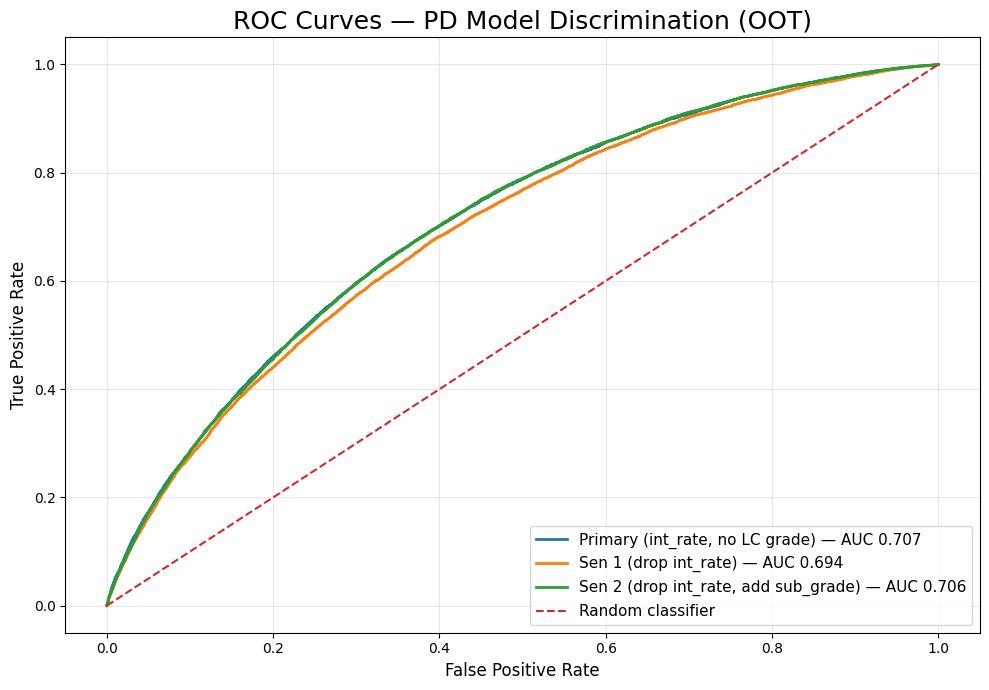

In [112]:
# ============================================================
# ROC curves for PD24M model discrimination
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Choose which split to plot
split_name = 'oot'   # options: 'train', 'valid', 'oot'

if split_name == 'train':
    y_plot = y_train
elif split_name == 'valid':
    y_plot = y_valid
elif split_name == 'oot':
    y_plot = y_oot
else:
    raise ValueError("split_name must be one of: 'train', 'valid', 'oot'")

# Friendly labels for plot
model_labels = {
    'base': 'Primary (int_rate, no LC grade)',
    'sens1_no_int_rate': 'Sen 1 (drop int_rate)',
    'sens2_with_subgrade': 'Sen 2 (drop int_rate, add sub_grade)'
}

plt.figure(figsize=(10, 7))

for model_name, label in model_labels.items():
    y_pred = predictions[model_name][split_name]
    
    fpr, tpr, thresholds = roc_curve(y_plot, y_pred)
    auc_value = roc_auc_score(y_plot, y_pred)
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{label} — AUC {auc_value:.3f}"
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5, label='Random classifier')

plt.title(f"ROC Curves — PD Model Discrimination ({split_name.upper()})", fontsize=18)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

fig_roc_by_model = plt.gcf()   # grabs the current figure
#plt.savefig("roc_curves_pd24.png", dpi=300, bbox_inches="tight")
plt.show()

### Calibration Plot and Table

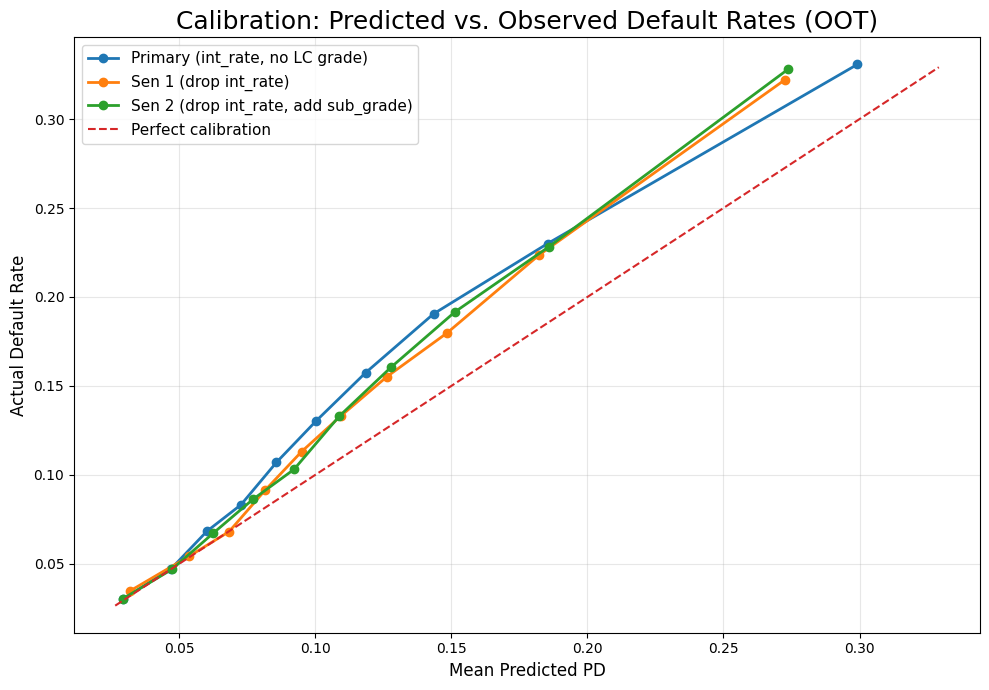

In [113]:
# ============================================================
# Calibration plot: predicted vs observed default rates
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calibration_by_quantile(y_true, y_pred, n_bins=10):
    """
    Groups loans into quantile bins by predicted PD and compares
    mean predicted PD with observed default rate in each bin.
    """
    df_cal = pd.DataFrame({
        'y': np.asarray(y_true),
        'pd_pred': np.asarray(y_pred)
    })
    
    df_cal['bin'] = pd.qcut(
        df_cal['pd_pred'],
        q=n_bins,
        labels=False,
        duplicates='drop'
    ) + 1
    
    cal = (
        df_cal
        .groupby('bin')
        .agg(
            n=('y', 'size'),
            mean_pred_pd=('pd_pred', 'mean'),
            actual_default_rate=('y', 'mean'),
            defaults=('y', 'sum')
        )
        .reset_index()
    )
    
    cal['actual_over_pred'] = cal['actual_default_rate'] / cal['mean_pred_pd']
    
    return cal


# Choose split
split_name = 'oot'   # options: 'train', 'valid', 'oot'

if split_name == 'train':
    y_plot = y_train
elif split_name == 'valid':
    y_plot = y_valid
elif split_name == 'oot':
    y_plot = y_oot
else:
    raise ValueError("split_name must be one of: 'train', 'valid', 'oot'")


model_labels = {
    'base': 'Primary (int_rate, no LC grade)',
    'sens1_no_int_rate': 'Sen 1 (drop int_rate)',
    'sens2_with_subgrade': 'Sen 2 (drop int_rate, add sub_grade)'
}


# Build calibration tables
calibration_tables = {}

for model_name in model_labels:
    calibration_tables[model_name] = calibration_by_quantile(
        y_true=y_plot,
        y_pred=predictions[model_name][split_name],
        n_bins=10
    )


# ----------------------------
# Plot
# ----------------------------

plt.figure(figsize=(10, 7))

for model_name, label in model_labels.items():
    cal = calibration_tables[model_name]
    
    plt.plot(
        cal['mean_pred_pd'],
        cal['actual_default_rate'],
        marker='o',
        linewidth=2,
        label=label
    )

# Perfect calibration line
all_x = pd.concat([
    calibration_tables[m]['mean_pred_pd'] for m in calibration_tables
])

x_min = all_x.min() * 0.9
x_max = all_x.max() * 1.1

plt.plot(
    [x_min, x_max],
    [x_min, x_max],
    linestyle='--',
    linewidth=1.5,
    label='Perfect calibration'
)

plt.title(f"Calibration: Predicted vs. Observed Default Rates ({split_name.upper()})", fontsize=18)
plt.xlabel("Mean Predicted PD", fontsize=12)
plt.ylabel("Actual Default Rate", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

fig_cal_overlay = plt.gcf() #capture the current figure
#plt.savefig(f"calibration_pd_model_{split_name}.png", dpi=300, bbox_inches="tight")
plt.show()

In [114]:
# ============================================================
# Decile calibration table for base PD24M model — OOT sample
# ============================================================

base_calibration_oot = calibration_tables['base'].copy()

base_calibration_oot_display = base_calibration_oot.rename(columns={
    'bin': 'pd_decile',
    'n': 'num_loans',
    'mean_pred_pd': 'mean_predicted_pd',
    'actual_default_rate': 'observed_default_rate',
    'actual_over_pred': 'observed_to_predicted_ratio'
})

base_calibration_oot_display

,pd_decile,num_loans,mean_predicted_pd,observed_default_rate,defaults,observed_to_predicted_ratio
0,1,9769,0.029537,0.030300,296,1.025842
1,2,9769,0.047082,0.047292,462,1.004461
2,3,9769,0.060231,0.068380,668,1.135279
3,4,9769,0.072713,0.083222,813,1.144529
4,5,9769,0.085762,0.107073,1046,1.248490
5,6,9769,0.100447,0.130515,1275,1.299336
6,7,9769,0.118516,0.157437,1538,1.328402
7,8,9769,0.143461,0.190501,1861,1.327895
8,9,9769,0.185364,0.230013,2247,1.240874
9,10,9769,0.299215,0.330740,3231,1.105359


### Default Drivers: Coefficients and Odds Ratios

In [115]:
# ============================================================
# Reference categories for drop-first one-hot encoding
# ============================================================

def get_reference_categories(pipe, categorical_features):
    preprocessor = pipe.named_steps['preprocess']
    cat_pipe = preprocessor.named_transformers_['cat']
    onehot = cat_pipe.named_steps['onehot']
    
    rows = []
    
    for i, col in enumerate(categorical_features):
        categories = onehot.categories_[i]
        
        if onehot.drop_idx_ is not None:
            ref = categories[onehot.drop_idx_[i]]
        else:
            ref = None
        
        rows.append({
            'categorical_feature': col,
            'reference_category': ref
        })
    
    return pd.DataFrame(rows)


for model_name, pipe in fitted_models.items():
    print(f"\nReference categories — {model_name}")
    display(
        get_reference_categories(
            pipe,
            model_info[model_name]['categorical_features']
        )
    )


Reference categories — base


,categorical_feature,reference_category
0,purpose,car
1,home_ownership,ANY
2,verification_status,Not Verified



Reference categories — sens1_no_int_rate


,categorical_feature,reference_category
0,purpose,car
1,home_ownership,ANY
2,verification_status,Not Verified



Reference categories — sens2_with_subgrade


,categorical_feature,reference_category
0,purpose,car
1,home_ownership,ANY
2,verification_status,Not Verified
3,sub_grade,A1


In [116]:
# ============================================================
# Default Drivers: Coefficients and Odds Ratios
# ============================================================

import numpy as np
import pandas as pd

driver_model_labels = {
    'base': 'Primary Model',
    'sens1_no_int_rate': 'Sen 1 (drop int_rate)',
    'sens2_with_subgrade': 'Sen 2 (drop int_rate, add sub_grade)'
}


def clean_feature_name(name):
    rename_map = {
        'fico_avg': 'fico',
        'emp_length_years': 'emp_length',
        'credit_history_months': 'credit_history'
    }
    return rename_map.get(name, name)


def get_model_feature_names(pipe, numeric_features, categorical_features):
    """
    Reconstructs feature names in the same order as the ColumnTransformer output:
    1. standardized numeric variables
    2. numeric missing indicators
    3. one-hot categorical variables
    """
    preprocessor = pipe.named_steps['preprocess']
    
    # 1. Numeric variables
    num_names = [clean_feature_name(c) for c in numeric_features]
    
    # 2. Missing indicators
    miss_transformer = preprocessor.named_transformers_['miss']
    
    if hasattr(miss_transformer, 'features_'):
        missing_indices = miss_transformer.features_
        miss_names = [
            clean_feature_name(numeric_features[i]) + '_missing'
            for i in missing_indices
        ]
    else:
        miss_names = []
    
    # 3. One-hot categorical variables
    cat_pipe = preprocessor.named_transformers_['cat']
    onehot = cat_pipe.named_steps['onehot']
    cat_names = list(onehot.get_feature_names_out(categorical_features))
    
    feature_names = num_names + miss_names + cat_names
    
    return feature_names


def extract_coefficients(model_name, pipe, numeric_features, categorical_features):
    feature_names = get_model_feature_names(
        pipe=pipe,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )
    
    coefs = pipe.named_steps['model'].coef_[0]
    
    if len(feature_names) != len(coefs):
        raise ValueError(
            f"{model_name}: feature-name length mismatch. "
            f"{len(feature_names)} names vs {len(coefs)} coefficients."
        )
    
    coef_df = pd.DataFrame({
        'model': model_name,
        'Feature': feature_names,
        'Coefficient': coefs
    })
    
    coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])
    coef_df['abs_coef'] = coef_df['Coefficient'].abs()
    
    coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
    
    return coef_df


# ----------------------------
# Extract, print, and save
# ----------------------------

coef_tables = []

for model_name, label in driver_model_labels.items():
    pipe = fitted_models[model_name]
    info = model_info[model_name]
    
    coef_df = extract_coefficients(
        model_name=model_name,
        pipe=pipe,
        numeric_features=info['numeric_features'],
        categorical_features=info['categorical_features']
    )
    
    coef_tables.append(coef_df)
    
    top15 = (
        coef_df
        .sort_values('abs_coef', ascending=False)
        .head(15)
        [['Feature', 'Coefficient', 'Odds Ratio']]
    )
    
    top_positive = (
        coef_df[coef_df['Coefficient'] > 0]
        .sort_values('Coefficient', ascending=False)
        .head(10)
        [['Feature', 'Coefficient', 'Odds Ratio', 'abs_coef']]
    )
    
    top_negative = (
        coef_df[coef_df['Coefficient'] < 0]
        .sort_values('Coefficient', ascending=True)
        .head(10)
        [['Feature', 'Coefficient', 'Odds Ratio', 'abs_coef']]
    )
    
    print(f"\nTop 15 Default Drivers — {label}:\n")
    print(top15.to_string(index=False))
    
    print("\nTop Positive Drivers:\n")
    print(top_positive.to_string(index=False))
    
    print("\nTop Negative Drivers:\n")
    print(top_negative.to_string(index=False))


coef_all_models = pd.concat(coef_tables, ignore_index=True)

#coef_all_models.to_csv(
#    "pd_model_coefficients_all_models.csv",
#    index=False
#)

print("\nCoefficient table saved to pd_model_coefficients_all_models.csv")


Top 15 Default Drivers — Primary Model:

                     Feature  Coefficient  Odds Ratio
pub_rec_bankruptcies_missing     0.619174    1.857393
     home_ownership_MORTGAGE    -0.574283    0.563108
          home_ownership_OWN    -0.515947    0.596935
             purpose_wedding    -0.465466    0.627842
      purpose_small_business     0.454268    1.575021
         home_ownership_RENT    -0.414662    0.660563
                    int_rate     0.333269    1.395523
          emp_length_missing     0.321570    1.379292
            purpose_vacation    -0.242467    0.784689
         purpose_credit_card    -0.232807    0.792306
              purpose_moving     0.231455    1.260433
               purpose_house    -0.227053    0.796879
                  annual_inc    -0.212742    0.808365
        acc_open_past_24mths     0.203207    1.225325
          revol_util_missing     0.158726    1.172017

Top Positive Drivers:

                     Feature  Coefficient  Odds Ratio  abs_coef
pub_re

### Calibration Sensitivity: Validation-Based Intercept Adjustment

As a sensitivity check, the base model is recalibrated using an intercept-only adjustment estimated on the validation sample, without changing loan risk rankings.

The calibration shift is fit using the 2015 validation sample and then applied to train, validation, and OOT predictions. The raw base-model PD remains the primary output for the macro/vintage multiplier framework, while the calibrated PD is retained as a robustness check.

In [117]:
# ============================================================
# Calibration sensitivity: intercept-only adjustment
# Base model only
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import brentq
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)


# ----------------------------
# Helper functions
# ----------------------------

def logit(p, eps=1e-8):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def fit_intercept_calibration(y_cal, p_cal):
    """
    Estimate one intercept shift delta such that the mean calibrated PD
    matches the observed default rate in the calibration sample.
    """
    y_cal = np.asarray(y_cal)
    p_cal = np.asarray(p_cal)
    
    z = logit(p_cal)
    target_rate = y_cal.mean()
    
    def objective(delta):
        return sigmoid(z + delta).mean() - target_rate
    
    delta = brentq(objective, -10, 10)
    return delta


def apply_intercept_calibration(p, delta):
    return sigmoid(logit(p) + delta)


def evaluate_prediction_set(y_true, p, model_label, split_name):
    ks, ks_threshold = ks_statistic(y_true, p)
    
    return {
        'model': model_label,
        'split': split_name,
        'n': len(y_true),
        'default_rate': np.mean(y_true),
        'mean_pred_pd': np.mean(p),
        'auc': roc_auc_score(y_true, p),
        'ks': ks,
        'ks_threshold': ks_threshold,
        'avg_precision': average_precision_score(y_true, p),
        'brier': brier_score_loss(y_true, p),
        'log_loss': log_loss(y_true, p)
    }


# ----------------------------
# Raw base predictions
# ----------------------------

p_base_train = predictions['base']['train']
p_base_valid = predictions['base']['valid']
p_base_oot   = predictions['base']['oot']


# ----------------------------
# Fit calibration shift on validation only
# ----------------------------

delta_base = fit_intercept_calibration(
    y_cal=y_valid.values,
    p_cal=p_base_valid
)

print("Validation-based calibration delta for base model:", round(delta_base, 4))


# ----------------------------
# Apply same shift to all splits
# ----------------------------

p_base_cal_train = apply_intercept_calibration(p_base_train, delta_base)
p_base_cal_valid = apply_intercept_calibration(p_base_valid, delta_base)
p_base_cal_oot   = apply_intercept_calibration(p_base_oot,   delta_base)


# Store calibrated predictions
calibrated_predictions = {
    'base_calibrated': {
        'train': p_base_cal_train,
        'valid': p_base_cal_valid,
        'oot': p_base_cal_oot
    }
}

calibration_deltas = {
    'base': delta_base
}


# ----------------------------
# Compare raw vs calibrated base model
# ----------------------------

cal_metric_rows = []

for split_name, y_true, p_raw, p_cal in [
    ('train', y_train, p_base_train, p_base_cal_train),
    ('valid', y_valid, p_base_valid, p_base_cal_valid),
    ('oot',   y_oot,   p_base_oot,   p_base_cal_oot)
]:
    cal_metric_rows.append(
        evaluate_prediction_set(y_true, p_raw, 'base_raw', split_name)
    )
    cal_metric_rows.append(
        evaluate_prediction_set(y_true, p_cal, 'base_calibrated', split_name)
    )

calibration_sensitivity_df = pd.DataFrame(cal_metric_rows)

calibration_sensitivity_display = calibration_sensitivity_df.copy()

for col in [
    'default_rate', 'mean_pred_pd', 'auc', 'ks',
    'ks_threshold', 'avg_precision', 'brier', 'log_loss'
]:
    calibration_sensitivity_display[col] = calibration_sensitivity_display[col].round(4)

calibration_sensitivity_display

Validation-based calibration delta for base model: 0.2467


,model,split,n,default_rate,mean_pred_pd,auc,ks,ks_threshold,avg_precision,brier,log_loss
0,base_raw,train,106544,0.1132,0.1132,0.6802,0.2609,0.1073,0.2082,0.0961,0.3324
1,base_calibrated,train,106544,0.1132,0.1389,0.6802,0.2609,0.1334,0.2082,0.0969,0.3355
2,base_raw,valid,95766,0.1345,0.1096,0.7090,0.3072,0.1093,0.2696,0.1096,0.3667
3,base_calibrated,valid,95766,0.1345,0.1345,0.7090,0.3072,0.1357,0.2696,0.1086,0.3633
4,base_raw,oot,97690,0.1375,0.1142,0.7068,0.3036,0.1056,0.2732,0.1114,0.3717
5,base_calibrated,oot,97690,0.1375,0.1397,0.7068,0.3036,0.1313,0.2732,0.1107,0.3689


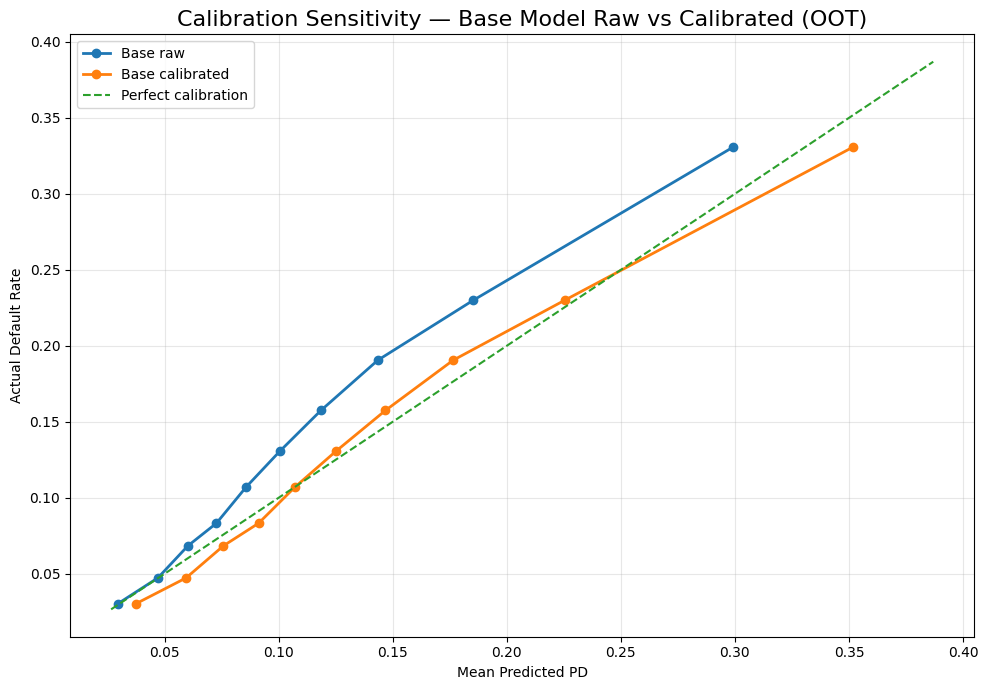

In [118]:
# ============================================================
# Calibration plot: raw vs calibrated base model
# ============================================================

import matplotlib.pyplot as plt

def calibration_by_quantile(y_true, y_pred, n_bins=10):
    df_cal = pd.DataFrame({
        'y': np.asarray(y_true),
        'pd_pred': np.asarray(y_pred)
    })
    
    df_cal['bin'] = pd.qcut(
        df_cal['pd_pred'],
        q=n_bins,
        labels=False,
        duplicates='drop'
    ) + 1
    
    cal = (
        df_cal
        .groupby('bin')
        .agg(
            n=('y', 'size'),
            mean_pred_pd=('pd_pred', 'mean'),
            actual_default_rate=('y', 'mean'),
            defaults=('y', 'sum')
        )
        .reset_index()
    )
    
    cal['actual_over_pred'] = cal['actual_default_rate'] / cal['mean_pred_pd']
    
    return cal


base_raw_cal_oot = calibration_by_quantile(y_oot, p_base_oot, n_bins=10)
base_adj_cal_oot = calibration_by_quantile(y_oot, p_base_cal_oot, n_bins=10)


plt.figure(figsize=(10, 7))

plt.plot(
    base_raw_cal_oot['mean_pred_pd'],
    base_raw_cal_oot['actual_default_rate'],
    marker='o',
    linewidth=2,
    label='Base raw'
)

plt.plot(
    base_adj_cal_oot['mean_pred_pd'],
    base_adj_cal_oot['actual_default_rate'],
    marker='o',
    linewidth=2,
    label='Base calibrated'
)

x_min = min(
    base_raw_cal_oot['mean_pred_pd'].min(),
    base_adj_cal_oot['mean_pred_pd'].min()
) * 0.9

x_max = max(
    base_raw_cal_oot['mean_pred_pd'].max(),
    base_adj_cal_oot['mean_pred_pd'].max()
) * 1.1

plt.plot(
    [x_min, x_max],
    [x_min, x_max],
    linestyle='--',
    linewidth=1.5,
    label='Perfect calibration'
)

plt.title("Calibration Sensitivity — Base Model Raw vs Calibrated (OOT)", fontsize=16)
plt.xlabel("Mean Predicted PD")
plt.ylabel("Actual Default Rate")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()

fig_cal_sens = plt.gcf() #capture the current figure
#plt.savefig("calibration_sensitivity_base_oot.png", dpi=300, bbox_inches="tight")
plt.show()

## Scoring the Full Terminal Set
--- Export Loan-Level PD Predictions for Macro Linkage

This section scores the full eligible modeling sample using the fitted base PD24M model and exports loan-level predicted default probabilities for the second-stage macro/satellite model.

Two PD measures are exported:

* `pd24m_hat_raw`: the raw predicted 24-month default probability from the base model.
* `pd24m_hat_calibrated`: the validation-calibrated version using the intercept-only calibration adjustment.

The raw PD is retained as the main loan-level model output because the second-stage multiplier model is designed to explain systematic deviations between realized defaults and loan-level expected defaults. The calibrated PD is exported as a robustness check.

These loan-level PDs are not yet quarterly expected defaults. In Macro linkage stage next, each loan’s 24-month PD will be allocated across loan-age quarters using an empirical seasoning/default-age curve. Expected defaults will then be aggregated by calendar quarter and compared with realized defaults to construct the default multiplier.


In [119]:
# ============================================================
# Export loan-level PD24M predictions for Layer 2
# Raw base PD + calibrated base PD
# ============================================================

import numpy as np
import pandas as pd

# ----------------------------
# Helper functions
# ----------------------------

def logit(p, eps=1e-8):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def apply_intercept_calibration(p, delta):
    return sigmoid(logit(p) + delta)


def add_engineered_features_for_scoring(df_in):
    """
    Apply the same feature engineering used for the PD24M model.
    """
    df_out = df_in.copy()
    
    # Ensure dates are datetime
    df_out['issue_d'] = pd.to_datetime(df_out['issue_d'], errors='coerce')
    df_out['earliest_cr_line'] = pd.to_datetime(df_out['earliest_cr_line'], errors='coerce')
    
    # term: "36 months" -> 36
    if 'term_months' not in df_out.columns:
        df_out['term_months'] = (
            df_out['term']
            .astype(str)
            .str.extract(r'(\d+)')[0]
            .astype(float)
        )
    
    # emp_length: convert text to years
    if 'emp_length_years' not in df_out.columns:
        emp = df_out['emp_length'].astype(str).str.strip()
        
        df_out['emp_length_years'] = np.select(
            [
                emp.str.contains('10\\+', na=False),
                emp.str.contains('< 1', na=False),
                emp.str.contains('nan', case=False, na=False)
            ],
            [
                10.0,
                0.0,  # 0.5, earlier error
                np.nan
            ],
            default=emp.str.extract(r'(\d+)')[0].astype(float)
        )
    


    # FICO average
    if 'fico_avg' not in df_out.columns:
        df_out['fico_avg'] = (
            pd.to_numeric(df_out['fico_range_low'], errors='coerce') +
            pd.to_numeric(df_out['fico_range_high'], errors='coerce')
        ) / 2
    
    # Credit history length in months at origination
    if 'credit_history_months' not in df_out.columns:
        df_out['credit_history_months'] = (
            (df_out['issue_d'].dt.year - df_out['earliest_cr_line'].dt.year) * 12 +
            (df_out['issue_d'].dt.month - df_out['earliest_cr_line'].dt.month)
        )
    
    # Numeric conversions
    numeric_to_convert = [
        'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
        'fico_range_low', 'fico_range_high', 'delinq_2yrs', 'inq_last_6mths',
        'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
        'pub_rec_bankruptcies', 'mort_acc', 'acc_open_past_24mths',
        'term_months', 'emp_length_years', 'fico_avg', 'credit_history_months'
    ]
    
    for col in numeric_to_convert:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors='coerce')
    
    return df_out


# ----------------------------
# Score full eligible modeling data
# ----------------------------

# Start from full eligible PD24M modeling data
score_source = df_model.copy()

print("Initial df_model shape:", score_source.shape)

# If eligible_24m exists, enforce it
if 'eligible_24m' in score_source.columns:
    score_source = score_source[score_source['eligible_24m'] == True].copy()
    print("After eligible_24m filter:", score_source.shape)
else:
    print("No eligible_24m column found; assuming df_model was already filtered.")
# keeping loans that defaulted within 24 months.

score_df = add_engineered_features_for_scoring(score_source)

print("Final scoring shape:", score_df.shape)



base_features = feature_sets['base']

# Check required features
missing_features = [c for c in base_features if c not in score_df.columns]
assert not missing_features, f"Missing base-model features in score_df: {missing_features}"

# Raw base PD24M prediction
score_df['pd24m_hat_raw'] = fitted_models['base'].predict_proba(
    score_df[base_features]
)[:, 1]

# Calibrated base PD24M prediction
# Requires delta_base from the calibration sensitivity block
score_df['pd24m_hat_calibrated'] = apply_intercept_calibration(
    score_df['pd24m_hat_raw'].values,
    delta_base
)


# ----------------------------
# Add useful time fields for Layer 2
# ----------------------------

score_df['issue_q'] = score_df['issue_d'].dt.to_period('Q')

if 'default_d_proxy' in score_df.columns:
    score_df['default_d_proxy'] = pd.to_datetime(score_df['default_d_proxy'], errors='coerce')
    score_df['default_q'] = score_df['default_d_proxy'].dt.to_period('Q')


# ----------------------------
# Export compact Layer 2 input
# ----------------------------

# Keep loan_id if available; otherwise create row_id
if 'loan_id' not in score_df.columns:
    score_df = score_df.reset_index(drop=False).rename(columns={'index': 'loan_row_id'})
    id_cols = ['loan_row_id']
else:
    id_cols = ['loan_id']

candidate_export_cols = (
    id_cols +
    [
        'issue_d',
        'issue_q',
        'term_months',
        'loan_status',
        'default_24m',
        'default_d_proxy',
        'default_q',
        'pd24m_hat_raw',
        'pd24m_hat_calibrated',
        'last_pymnt_d',
        'loan_amnt'
    ]
)

export_cols = [c for c in candidate_export_cols if c in score_df.columns]

layer2_loan_pd = score_df[export_cols].copy()

# Period columns do not always export cleanly to CSV, so convert to string
for col in ['issue_q', 'default_q']:
    if col in layer2_loan_pd.columns:
        layer2_loan_pd[col] = layer2_loan_pd[col].astype(str).replace('NaT', np.nan)

layer2_loan_pd.to_csv("scored_loan_level_pd.csv", index=False)

try:
    layer2_loan_pd.to_parquet("scored_loan_level_pd.parquet", index=False)
    print("Saved: scored_loan_level_pd.csv and scored_loan_level_pd.parquet")
except Exception as e:
    print("Saved: scored_loan_level_pd.csv")
    print("Parquet skipped:", e)

print("\nExport shape:", layer2_loan_pd.shape)
print("\nMean PDs:")
print(layer2_loan_pd[['pd24m_hat_raw', 'pd24m_hat_calibrated']].mean().round(4))

layer2_loan_pd.head()

Initial df_model shape: (1310558, 39)
After eligible_24m filter: (1310558, 39)


C:\Users\shanx\AppData\Local\Temp\ipykernel_34196\3083129713.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_out['earliest_cr_line'] = pd.to_datetime(df_out['earliest_cr_line'], errors='coerce')


Final scoring shape: (1310558, 43)
Saved: scored_loan_level_pd.csv and scored_loan_level_pd.parquet

Export shape: (1310558, 12)

Mean PDs:
pd24m_hat_raw           0.1122
pd24m_hat_calibrated    0.1376
dtype: float64


,loan_row_id,issue_d,issue_q,term_months,loan_status,default_24m,default_d_proxy,default_q,pd24m_hat_raw,pd24m_hat_calibrated,last_pymnt_d,loan_amnt
0,0,2015-12-31,2015Q4,36.0,Fully Paid,0,NaT,NaN,0.085047,0.106311,2019-01-31,3600.0
1,1,2015-12-31,2015Q4,36.0,Fully Paid,0,NaT,NaN,0.143001,0.175967,2016-06-30,24700.0
2,2,2015-12-31,2015Q4,60.0,Fully Paid,0,NaT,NaN,0.077608,0.097209,2017-06-30,20000.0
3,3,2015-12-31,2015Q4,60.0,Current,0,NaT,NaN,0.072135,0.090489,2019-02-28,35000.0
4,4,2015-12-31,2015Q4,60.0,Fully Paid,0,NaT,NaN,0.270779,0.322129,2016-07-31,10400.0


In [120]:
# ===============================================
# pd export validation for use in Satellite Model 
# ===============================================

print("=" * 64)
print("LAYER 2 EXPORT VALIDATION")
print("=" * 64)

flags = []

# --- [0] Shapes & headline rates (printed once) -----------------------------
print("\n[0] Shapes & headline rates")
print(f"  df_model rows:        {len(df_model)}")
print(f"  layer2 export rows:   {len(layer2_loan_pd)}")
if len(df_model) != len(layer2_loan_pd):
    flags.append("export row count != df_model row count")

if 'default_24m' in layer2_loan_pd.columns:
    print(f"  default_24m rate:     {layer2_loan_pd['default_24m'].mean():.4f}")

print("  mean PDs:")
print(layer2_loan_pd[['pd24m_hat_raw', 'pd24m_hat_calibrated']].mean().round(4).to_string())

# --- [1] emp_length encoding integrity --------------------------------------
print("\n[1] emp_length_years distribution (scored)")
ely = score_df['emp_length_years']
print(ely.value_counts(dropna=False).sort_index().to_string())

allowed = set(range(0, 11))  # {0..10}
unexpected = sorted(v for v in ely.dropna().unique() if float(v) not in allowed)
if unexpected:
    flags.append(f"emp_length_years has unexpected values: {unexpected}")
    print("  -> CHECK: unexpected values", unexpected)
else:
    print("  -> OK: values within {0..10, NaN}")

if (ely == 0.5).any():
    flags.append("emp_length_years contains 0.5 (old <1yr encoding bug)")
    print("  -> CHECK: found 0.5 (legacy <1yr bug)")
else:
    print("  -> OK: no 0.5 values (legacy bug absent)")

# --- [2] PD range, NaNs, calibration lift, rank-order preservation ----------
print("\n[2] PD integrity")
for col in ['pd24m_hat_raw', 'pd24m_hat_calibrated']:
    s = score_df[col]
    print(f"  {col}: min={s.min():.4f}  mean={s.mean():.4f}  max={s.max():.4f}  nan={s.isna().sum()}")
    if s.min() < 0 or s.max() > 1:
        flags.append(f"{col} outside [0,1]")
    if s.isna().any():
        flags.append(f"{col} contains {s.isna().sum()} NaNs")

lift = score_df['pd24m_hat_calibrated'].mean() / score_df['pd24m_hat_raw'].mean()
print(f"  calibration lift (cal/raw mean) = {lift:.4f}  (expect ~1.2)")

rank_corr = (
    pd.Series(score_df['pd24m_hat_raw']).rank()
      .corr(pd.Series(score_df['pd24m_hat_calibrated']).rank())
)
print(f"  rank corr raw vs calibrated     = {rank_corr:.6f}  (expect 1.000000)")
if rank_corr < 0.999999:
    flags.append("calibration changed rank ordering — should be monotone")

# --- [3] Timing integrity: default_q vs default_24m -------------------------
print("\n[3] default_q timing integrity")
if 'default_q' in layer2_loan_pd.columns:
    bad_missing_default_q = layer2_loan_pd[
        (layer2_loan_pd['default_24m'] == 1) & (layer2_loan_pd['default_q'].isna())
    ]
    nondef_with_default_q = layer2_loan_pd[
        (layer2_loan_pd['default_24m'] == 0) & (layer2_loan_pd['default_q'].notna())
    ]
    n_bad = bad_missing_default_q.shape[0]
    n_mirror = nondef_with_default_q.shape[0]
    print(f"  defaults (==1) missing default_q:        {n_bad}   (should be rare/0)")
    print(f"  non-defaults (==0) with a default_q:     {n_mirror}   (usually benign)")
    if n_bad > 0:
        flags.append(f"{n_bad} defaulted loans have no default_q (drop from satellite panel)")
else:
    print("  default_q not in export — skipped")

# --- [4] Censoring integrity: non-defaults must have full 24m window --------
print("\n[4] censoring integrity (target definition)")
if {'available_months', 'default_24m'}.issubset(df_model.columns):
    bad_censored = df_model[
        (df_model['default_24m'] == 0) & (df_model['available_months'] < 24)
    ]
    n_censored = bad_censored.shape[0]
    print(f"  non-default loans with <24 months observed: {n_censored}   (should be 0)")
    if n_censored > 0:
        flags.append(f"{n_censored} non-default loans have <24m observation (censoring leak in target)")
else:
    print("  available_months/default_24m not in df_model — skipped")

# --- [5] loan_status x default_24m crosstab (eyeball) -----------------------
if 'loan_status' in layer2_loan_pd.columns:
    print("\n[5] loan_status x default_24m")
    print(pd.crosstab(layer2_loan_pd['loan_status'],
                      layer2_loan_pd['default_24m'], margins=True).to_string())

# --- Verdict ----------------------------------------------------------------
print("\n" + "=" * 64)
if flags:
    print("VALIDATION FLAGS:")
    for f in flags:
        print("   -", f)
else:
    print("ALL CHECKS PASSED — export looks clean for Layer 2.")
print("=" * 64)

LAYER 2 EXPORT VALIDATION

[0] Shapes & headline rates
  df_model rows:        1310558
  layer2 export rows:   1310558
  default_24m rate:     0.1279
  mean PDs:
pd24m_hat_raw           0.1122
pd24m_hat_calibrated    0.1376

[1] emp_length_years distribution (scored)
emp_length_years
0.0     101694
1.0      85523
2.0     117491
3.0     103907
4.0      77685
5.0      81425
6.0      61075
7.0      58366
8.0      62181
9.0      51144
10.0    437780
NaN      72287
  -> OK: values within {0..10, NaN}
  -> OK: no 0.5 values (legacy bug absent)

[2] PD integrity
  pd24m_hat_raw: min=0.0000  mean=0.1122  max=1.0000  nan=0
  pd24m_hat_calibrated: min=0.0000  mean=0.1376  max=1.0000  nan=0
  calibration lift (cal/raw mean) = 1.2259  (expect ~1.2)
  rank corr raw vs calibrated     = 1.000000  (expect 1.000000)

[3] default_q timing integrity
  defaults (==1) missing default_q:        0   (should be rare/0)
  non-defaults (==0) with a default_q:     0   (usually benign)

[4] censoring integrity (t

## Result Figures and Tables

This section assembles the output tables and figures for the PD model, as seen in writeups and other project presentations.

In [121]:
# ------------------------------------------------------------
# Artifact setup: output folder, display + Gini helpers
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ARTIFACT_DIR = "artifacts_component1"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

def gini_from_auc(auc):
    return 2.0 * auc - 1.0

# Consistent model order and labels for every artifact
MODEL_ORDER = ['base', 'sens1_no_int_rate', 'sens2_with_subgrade']
MODEL_LABELS = {
    'base': 'Primary (int_rate, no LC grade)',
    'sens1_no_int_rate': 'Sen 1 (drop int_rate)',
    'sens2_with_subgrade': 'Sen 2 (drop int_rate, add sub_grade)',
}

print("Artifacts will be written to:", os.path.abspath(ARTIFACT_DIR))


Artifacts will be written to: c:\Users\shanx\Dropbox\STG\STG26CODES\Git\Projects\StressTesting\artifacts_component1


### Table 1.1 — Cohort waterfall and partition summary

Two stacked views of the data lineage:

1. **Waterfall** — row counts from the raw loaded file down to the final modeling
   sample, showing each exclusion (insufficient 24-month follow-up, ambiguous status,
   missing dates/status or unresolved default timing) and the stratified sample step.
2. **Partition** — N, 24-month default rate, and issue-date range for train (<2015),
   validation (2015), and OOT (>=2016).


In [122]:
# ------------------------------------------------------------
# Table 1a — Cohort waterfall (raw -> modeling sample -> working sample)
# ------------------------------------------------------------

n_raw            = len(df)
n_insuff_follow  = int((~df['eligible_24m']).sum())
n_ambiguous      = int((df['eligible_24m'] & df['is_ambiguous_status']).sum())
n_model          = len(df_model)                      # default_24m is non-null
n_other_drops    = n_raw - n_insuff_follow - n_ambiguous - n_model
n_working        = len(sample)                         # stratified working sample

waterfall = pd.DataFrame([
    ("Raw loans loaded (selected columns)",            n_raw,           np.nan),
    ("(-) Insufficient 24m follow-up",                 -n_insuff_follow, np.nan),
    ("(-) Ambiguous loan status",                      -n_ambiguous,     np.nan),
    ("(-) Missing date/status or unresolved timing",   -n_other_drops,   np.nan),
    ("= Eligible modeling sample (df_model)",          n_model,          df_model['default_24m'].mean()),
    ("Stratified working sample (sample)",             n_working,        sample['default_24m'].mean()),
], columns=["stage", "n_loans", "default_24m_rate"])

waterfall["default_24m_rate"] = waterfall["default_24m_rate"].round(4)
waterfall.to_csv(os.path.join(ARTIFACT_DIR, "table1.1a_cohort_waterfall.csv"), index=False)

print("Cohort waterfall")
print(waterfall.to_string(index=False))
waterfall


Cohort waterfall
                                       stage  n_loans  default_24m_rate
         Raw loans loaded (selected columns)  2260701               NaN
              (-) Insufficient 24m follow-up  -938854               NaN
                   (-) Ambiguous loan status   -10102               NaN
(-) Missing date/status or unresolved timing    -1187               NaN
       = Eligible modeling sample (df_model)  1310558            0.1279
          Stratified working sample (sample)   300000            0.1279


,stage,n_loans,default_24m_rate
0,Raw loans loaded (selected columns),2260701,NaN
1,(-) Insufficient 24m follow-up,-938854,NaN
2,(-) Ambiguous loan status,-10102,NaN
3,(-) Missing date/status or unresolved timing,-1187,NaN
4,= Eligible modeling sample (df_model),1310558,0.1279
5,Stratified working sample (sample),300000,0.1279


In [123]:
# ------------------------------------------------------------
# Table 1b — Train / validation / OOT partition summary
# ------------------------------------------------------------

def partition_row(name, frame):
    return {
        "partition": name,
        "vintage_rule": {
            "train": "issue_d < 2015",
            "valid": "2015 <= issue_d < 2016",
            "oot":   "issue_d >= 2016",
        }[name],
        "n_loans": len(frame),
        "default_24m_rate": round(frame['default_24m'].mean(), 4),
        "issue_d_min": str(frame['issue_d'].min().date()),
        "issue_d_max": str(frame['issue_d'].max().date()),
    }

partition = pd.DataFrame([
    partition_row("train", train),
    partition_row("valid", valid),
    partition_row("oot",   oot),
])

partition.to_csv(os.path.join(ARTIFACT_DIR, "table1.1b_partition_summary.csv"), index=False)

print("Partition summary")
print(partition.to_string(index=False))
partition


Partition summary
partition           vintage_rule  n_loans  default_24m_rate issue_d_min issue_d_max
    train         issue_d < 2015   106544            0.1132  2007-06-30  2014-12-31
    valid 2015 <= issue_d < 2016    95766            0.1345  2015-01-31  2015-12-31
      oot        issue_d >= 2016    97690            0.1375  2016-01-31  2016-12-31


,partition,vintage_rule,n_loans,default_24m_rate,issue_d_min,issue_d_max
0,train,issue_d < 2015,106544,0.1132,2007-06-30,2014-12-31
1,valid,2015 <= issue_d < 2016,95766,0.1345,2015-01-31,2015-12-31
2,oot,issue_d >= 2016,97690,0.1375,2016-01-31,2016-12-31


### Table 1.2 — Variable dictionary

Each model input with its definition, measurement timing relative to origination, the
transformation applied, and its encoding. 


In [124]:
# ------------------------------------------------------------
# Table 2 — Variable dictionary (static documentation table)
# ------------------------------------------------------------

# timing: "origination"      = known at/before loan funding;
#         "backward-looking" = credit-bureau history as of application.
#
# Encoding conventions (applied uniformly, stated once here):
#   - All NUMERIC features: median-imputed on the training split, then standardized
#     (StandardScaler). A binary "<feature>_missing" indicator is added for any numeric
#     feature that had missingness in training. Coefficients are therefore per-1-SD.
#   - All CATEGORICAL features: most-frequent impute, one-hot (drop-first), NOT scaled.
#     Coefficients are log-odds shifts vs. the dropped reference level.

var_dict_rows = [
    # feature, group, timing, definition, transform, encoding_note
    ("loan_amnt",            "loan terms",     "origination",      "Requested/funded loan amount (USD)",             "as-is",                    ""),
    ("term_months",          "loan terms",     "origination",      "Contractual term in months",                     "parsed from 'NN months'",  "values 36 or 60"),
    ("int_rate",             "loan terms",     "origination",      "Contractual interest rate (%)",                  "as-is",                    "EXCLUDED in Sen 1 & Sen 2"),
    ("installment",          "loan terms",     "origination",      "Monthly payment (USD)",                          "as-is",                    ""),
    ("annual_inc",           "borrower",       "origination",      "Self-reported annual income (USD)",              "as-is",                    ""),
    ("dti",                  "borrower",       "origination",      "Debt-to-income ratio",                           "as-is",                    ""),
    ("emp_length_years",     "borrower",       "origination",      "Employment length in years",                     "text -> years",            "<1yr=0.0, 1yr=1.0, ..., 10+=10.0 (train==score)"),
    ("fico_avg",             "credit history", "backward-looking", "Average of FICO low/high band at application",   "(low+high)/2",             ""),
    ("credit_history_months","credit history", "backward-looking", "Months from earliest credit line to issue date", "date diff",                "negatives set to NaN then imputed"),
    ("delinq_2yrs",          "credit history", "backward-looking", "Delinquencies in past 2 years",                  "as-is",                    ""),
    ("inq_last_6mths",       "credit history", "backward-looking", "Credit inquiries in past 6 months",              "as-is",                    ""),
    ("open_acc",             "credit history", "backward-looking", "Number of open credit lines",                    "as-is",                    ""),
    ("pub_rec",              "credit history", "backward-looking", "Number of derogatory public records",            "as-is",                    ""),
    ("revol_bal",            "credit history", "backward-looking", "Revolving balance (USD)",                        "as-is",                    ""),
    ("revol_util",           "credit history", "backward-looking", "Revolving line utilization (%)",                 "as-is",                    ""),
    ("total_acc",            "credit history", "backward-looking", "Total number of credit lines on file",           "as-is",                    ""),
    ("pub_rec_bankruptcies", "credit history", "backward-looking", "Number of public-record bankruptcies",           "as-is",                    ""),
    ("mort_acc",             "credit history", "backward-looking", "Number of mortgage accounts",                    "as-is",                    ""),
    ("acc_open_past_24mths", "credit history", "backward-looking", "Accounts opened in past 24 months",              "as-is",                    ""),
    ("purpose",              "categorical",    "origination",      "Stated loan purpose",                            "as-is",                    ""),
    ("home_ownership",       "categorical",    "origination",      "Home ownership status",                          "as-is",                    ""),
    ("verification_status",  "categorical",    "origination",      "Income verification status",                     "as-is",                    ""),
    ("sub_grade",            "LC proprietary", "origination",      "LendingClub sub-grade",                          "as-is",                    "ONLY in Sen 2"),
]

variable_dictionary = pd.DataFrame(
    var_dict_rows,
    columns=["feature", "group", "timing", "definition", "transformation", "encoding_note"]
)

# --- Derived columns -------------------------------------------------

# Categorical groups are one-hot (drop-first); everything else is numeric/standardized.
onehot_groups = {"categorical", "LC proprietary"}

def encoding(row):
    if row["group"] in onehot_groups:
        base = "one-hot (drop-first), most-frequent impute; not standardized"
    else:
        base = "numeric; median-imputed, standardized"
    return f"{base}; {row['encoding_note']}" if row["encoding_note"] else base

variable_dictionary["encoding"] = variable_dictionary.apply(encoding, axis=1)

# Coefficient scale (for reading Table 1.3): numeric = per-SD, categorical = log-odds vs reference.
variable_dictionary["coef_scale"] = np.where(
    variable_dictionary["group"].isin(onehot_groups),
    "log-odds vs reference",
    "per-1-SD",
)

# Name as it appears in the Table 1.3 coefficient tables (clean_feature_name aliases).
coef_name_alias = {
    "fico_avg": "fico",
    "emp_length_years": "emp_length",
    "credit_history_months": "credit_history",
}
variable_dictionary["coef_table_name"] = (
    variable_dictionary["feature"].map(coef_name_alias).fillna(variable_dictionary["feature"])
)

# Which feature set(s) each variable enters.
def in_sets(feat):
    flags = [name for name in MODEL_ORDER if feat in feature_sets[name]]
    return ", ".join(flags) if flags else "(not used)"

variable_dictionary["used_in"] = variable_dictionary["feature"].apply(in_sets)

# Final column order
variable_dictionary = variable_dictionary[
    ["feature", "coef_table_name", "group", "timing", "definition",
     "transformation", "encoding", "coef_scale", "used_in"]
]

variable_dictionary.to_csv(os.path.join(ARTIFACT_DIR, "table1.2_variable_dictionary.csv"), index=False)

print("Variable dictionary:", variable_dictionary.shape[0], "rows")
print("Note: numeric coefficients are per-1-SD; categorical/sub_grade are log-odds vs the dropped reference level.")
variable_dictionary

Variable dictionary: 23 rows
Note: numeric coefficients are per-1-SD; categorical/sub_grade are log-odds vs the dropped reference level.


,feature,coef_table_name,group,timing,definition,transformation,encoding,coef_scale,used_in
0,loan_amnt,loan_amnt,loan terms,origination,Requested/funded loan amount (USD),as-is,"numeric; median-imputed, standardized",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
1,term_months,term_months,loan terms,origination,Contractual term in months,parsed from 'NN months',"numeric; median-imputed, standardized; values ...",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
2,int_rate,int_rate,loan terms,origination,Contractual interest rate (%),as-is,"numeric; median-imputed, standardized; EXCLUDE...",per-1-SD,base
3,installment,installment,loan terms,origination,Monthly payment (USD),as-is,"numeric; median-imputed, standardized",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
4,annual_inc,annual_inc,borrower,origination,Self-reported annual income (USD),as-is,"numeric; median-imputed, standardized",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
5,dti,dti,borrower,origination,Debt-to-income ratio,as-is,"numeric; median-imputed, standardized",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
6,emp_length_years,emp_length,borrower,origination,Employment length in years,text -> years,"numeric; median-imputed, standardized; <1yr=0....",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
7,fico_avg,fico,credit history,backward-looking,Average of FICO low/high band at application,(low+high)/2,"numeric; median-imputed, standardized",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
8,credit_history_months,credit_history,credit history,backward-looking,Months from earliest credit line to issue date,date diff,"numeric; median-imputed, standardized; negativ...",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"
9,delinq_2yrs,delinq_2yrs,credit history,backward-looking,Delinquencies in past 2 years,as-is,"numeric; median-imputed, standardized",per-1-SD,"base, sens1_no_int_rate, sens2_with_subgrade"


### Table 1.3 — Coefficients across specifications (side by side)

In [125]:
# ------------------------------------------------------------
# Table 3 — Coefficient side-by-side (pivot of coef_all_models)
# ------------------------------------------------------------

# coef_all_models columns: model, Feature, Coefficient, Odds Ratio, abs_coef
coef_wide = (
    coef_all_models
    .pivot_table(index="Feature", columns="model", values="Coefficient", aggfunc="first")
    .reindex(columns=MODEL_ORDER)
)

odds_wide = (
    coef_all_models
    .pivot_table(index="Feature", columns="model", values="Odds Ratio", aggfunc="first")
    .reindex(columns=MODEL_ORDER)
)

# Order rows by importance in the primary model, then any sens-only features after
base_rank = (
    coef_all_models.loc[coef_all_models["model"] == "base"]
    .set_index("Feature")["abs_coef"]
)
coef_wide["_rank"] = coef_wide.index.map(base_rank).fillna(-1)
coef_wide = coef_wide.sort_values("_rank", ascending=False).drop(columns="_rank")
odds_wide = odds_wide.reindex(coef_wide.index)

coef_wide_display = coef_wide.rename(columns=MODEL_LABELS).round(4)
odds_wide_display = odds_wide.rename(columns=MODEL_LABELS).round(4)

coef_wide_display.to_csv(os.path.join(ARTIFACT_DIR, "table1.3a_coefficients_side_by_side.csv"))
odds_wide_display.to_csv(os.path.join(ARTIFACT_DIR, "table1.3b_odds_ratios_side_by_side.csv"))

print("Standardized coefficients (side by side):")
coef_wide_display


Standardized coefficients (side by side):


model,"Primary (int_rate, no LC grade)",Sen 1 (drop int_rate),"Sen 2 (drop int_rate, add sub_grade)"
Feature,,,
pub_rec_bankruptcies_missing,0.6192,0.6634,0.4136
home_ownership_MORTGAGE,-0.5743,-0.5599,-0.4606
home_ownership_OWN,-0.5159,-0.4761,-0.4043
purpose_wedding,-0.4655,-0.4608,-0.0747
purpose_small_business,0.4543,0.6328,0.7783
...,...,...,...
sub_grade_F4,NaN,NaN,1.3234
sub_grade_F3,NaN,NaN,1.2827
sub_grade_G5,NaN,NaN,1.5593


In [126]:
# Odds ratios, same ordering (companion to the coefficient table above)
print("Odds ratios (side by side):")
odds_wide_display


Odds ratios (side by side):


model,"Primary (int_rate, no LC grade)",Sen 1 (drop int_rate),"Sen 2 (drop int_rate, add sub_grade)"
Feature,,,
pub_rec_bankruptcies_missing,1.8574,1.9413,1.5122
home_ownership_MORTGAGE,0.5631,0.5712,0.6309
home_ownership_OWN,0.5969,0.6212,0.6675
purpose_wedding,0.6278,0.6308,0.9281
purpose_small_business,1.5750,1.8829,2.1777
...,...,...,...
sub_grade_F4,NaN,NaN,3.7560
sub_grade_F3,NaN,NaN,3.6063
sub_grade_G5,NaN,NaN,4.7553


### Table 1.4 — Discrimination and accuracy across splits

AUC, KS, Gini, Brier, and log-loss for all three specifications across train /
validation / OOT in one grid. Gini is derived as `2*AUC - 1`. Brier and log-loss are
included because the calibrated PD feeds Component 2, so level accuracy (not just
ranking) matters.


In [127]:
# ------------------------------------------------------------
# Table 4 — Performance grid (AUC, KS, Gini, Brier, log-loss) x split
# ------------------------------------------------------------

perf = metrics_df.copy()
perf["gini"] = gini_from_auc(perf["auc"])

split_order = ["train", "valid", "oot"]
metric_cols = ["auc", "gini", "ks", "brier", "log_loss"]

# Long -> wide: rows = (model, metric), columns = split
long = perf.melt(
    id_vars=["model", "split"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
)

performance_grid = (
    long.pivot_table(index=["model", "metric"], columns="split", values="value", aggfunc="first")
    .reindex(columns=split_order)
)

# Order rows: models in MODEL_ORDER, metrics in metric_cols order
performance_grid = performance_grid.reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, metric_cols], names=["model", "metric"])
).round(4)

performance_grid.to_csv(os.path.join(ARTIFACT_DIR, "table1.4_performance_grid.csv"))

print("Discrimination & accuracy by split:")
performance_grid


Discrimination & accuracy by split:


split                          train   valid     oot
model               metric                          
base                auc       0.6802  0.7090  0.7068
                    gini      0.3604  0.4180  0.4136
                    ks        0.2609  0.3072  0.3036
                    brier     0.0961  0.1096  0.1114
                    log_loss  0.3324  0.3667  0.3717
sens1_no_int_rate   auc       0.6724  0.6957  0.6939
                    gini      0.3448  0.3914  0.3877
                    ks        0.2471  0.2875  0.2830
                    brier     0.0964  0.1101  0.1123
                    log_loss  0.3342  0.3690  0.3752
sens2_with_subgrade auc       0.6819  0.7089  0.7063
                    gini      0.3638  0.4177  0.4125
                    ks        0.2634  0.3055  0.3034
                    brier     0.0959  0.1092  0.1116
                    log_loss  0.3319  0.3649  0.3716

### Table 1.5 — OOT Calibration

Table 1.5a reports overall average predicted PD against the actual observed default rate in the out-of-time sample, for both the raw base model and the intercept-calibrated base model.

Table 1.5b reports the decile calibration for the base model on OOT



In [128]:
# ------------------------------------------------------------
# Table 5 — Overall OOT calibration (raw vs calibrated base)
# ------------------------------------------------------------

y_oot_arr = np.asarray(y_oot)

def overall_calib(label, p):
    p = np.asarray(p)
    pred = p.mean()
    obs = y_oot_arr.mean()
    return {
        "model": label,
        "n": len(p),
        "mean_predicted_pd": round(pred, 4),
        "observed_default_rate": round(obs, 4),
        "actual_over_predicted": round(obs / pred, 4) if pred > 0 else np.nan,
    }

calibration_overall_oot = pd.DataFrame([
    overall_calib("base_raw",        predictions['base']['oot']),
    overall_calib("base_calibrated", p_base_cal_oot),
])

calibration_overall_oot.to_csv(os.path.join(ARTIFACT_DIR, "table1.5a_calibration_overall_oot.csv"), index=False)

# Re-save the decile table built earlier (cell with base_calibration_oot_display)
try:
    base_calibration_oot_display.to_csv(
        os.path.join(ARTIFACT_DIR, "table1.5b_base_calibration_deciles_oot.csv"), index=False
    )
    print("Saved decile calibration table from base_calibration_oot_display.")
except NameError:
    print("base_calibration_oot_display not found - run the decile calibration cell above first.")

print("\nOverall OOT calibration:")
print(calibration_overall_oot.to_string(index=False))
calibration_overall_oot


Saved decile calibration table from base_calibration_oot_display.

Overall OOT calibration:
          model     n  mean_predicted_pd  observed_default_rate  actual_over_predicted
       base_raw 97690             0.1142                 0.1375                 1.2041
base_calibrated 97690             0.1397                 0.1375                 0.9849


,model,n,mean_predicted_pd,observed_default_rate,actual_over_predicted
0,base_raw,97690,0.1142,0.1375,1.2041
1,base_calibrated,97690,0.1397,0.1375,0.9849


### Figure 1.1 — ROC across model specifications and across split

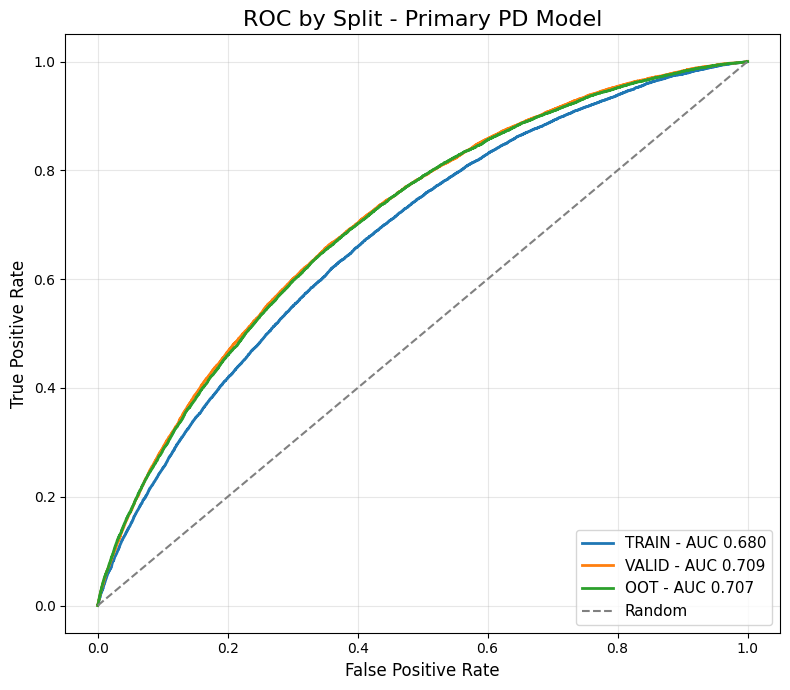

saved  artifacts_component1/fig1.1b_roc_by_model_oot.png


In [129]:
# ------------------------------------------------------------
# Figure 1.1a — ROC overlay across splits for the primary model
# holds the model fixed (the primary spec) and overlays the three splits, 
# so the OOT curve sitting near the train/validation curves is the visual evidence of generalization.
from sklearn.metrics import roc_curve, roc_auc_score

split_targets = {"train": y_train, "valid": y_valid, "oot": y_oot}

plt.figure(figsize=(8, 7))
for split_name in ["train", "valid", "oot"]:
    y_s = split_targets[split_name]
    p_s = predictions['base'][split_name]
    fpr, tpr, _ = roc_curve(y_s, p_s)
    auc_s = roc_auc_score(y_s, p_s)
    plt.plot(fpr, tpr, linewidth=2, label=f"{split_name.upper()} - AUC {auc_s:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="gray", label="Random")
plt.title("ROC by Split - Primary PD Model", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "fig1.1a_roc_by_split_primary.png"), dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 1.1b — ROC overlay across base models for OOT
# The per-model ROC on a single split is plotted earlier. 
# collect the per-model ROC:

try:
    fig_roc_by_model.savefig(
        os.path.join(ARTIFACT_DIR, "fig1.1b_roc_by_model_oot.png"),
        dpi=300, bbox_inches="tight"
    )
    print(f"saved  {ARTIFACT_DIR}/fig1.1b_roc_by_model_oot.png")
except NameError:
    print("SKIP: fig_roc_by_model not defined — run the per-model ROC cell (~32) first")



### Figure 1.2 — Calibration plot (OOT)

In [130]:
# Figure 2 — save the calibration figures (built in cells ~34 and ~41) into the artifact folder
saved, missing = [], []

for handle_name, out_name in [
    ("fig_cal_overlay", "fig1.2a_calibration_overlay_oot.png"),        # 3 specs, raw (cell ~34)
    ("fig_cal_sens",    "fig1.2b_calibration_base_raw_vs_cal_oot.png"),# base raw vs calibrated (cell ~41)
]:
    fig = globals().get(handle_name)
    if fig is not None:
        fig.savefig(os.path.join(ARTIFACT_DIR, out_name), dpi=300, bbox_inches="tight")
        saved.append(out_name)
    else:
        missing.append(handle_name)

for n in saved:
    print(f"saved  {ARTIFACT_DIR}/{n}")
for h in missing:
    print(f"SKIP: {h} not defined — run its plotting cell first")




saved  artifacts_component1/fig1.2a_calibration_overlay_oot.png
saved  artifacts_component1/fig1.2b_calibration_base_raw_vs_cal_oot.png


### Figure 1.3 — Rank ordering: observed default rate by PD decile (OOT)

Loans are sorted into deciles by predicted PD on OOT; the bars show the observed default
rate in each decile, with the mean predicted PD overlaid. A monotonic increase across
deciles is the rank-ordering evidence that pairs with the AUC/Gini numbers.


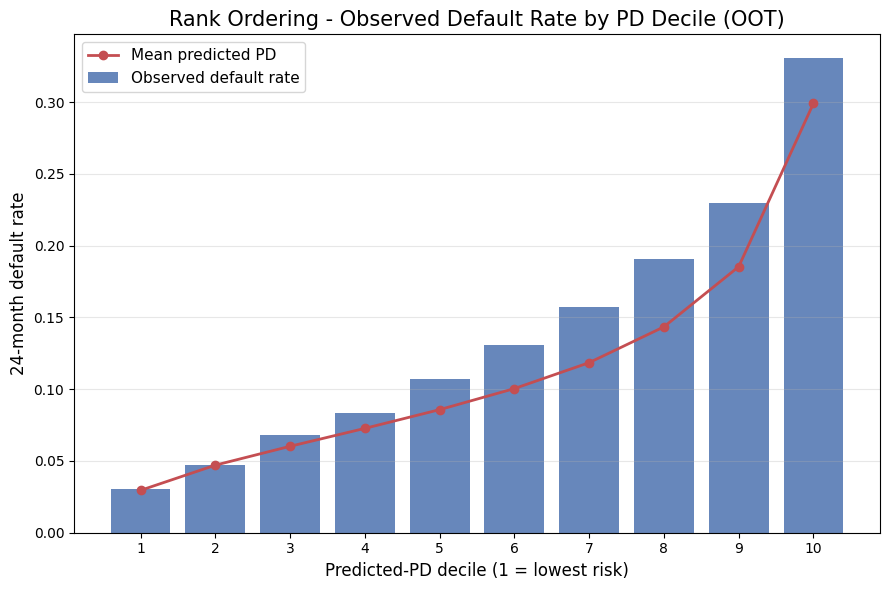

In [131]:
# ------------------------------------------------------------
# Figure 3 — Observed default rate by predicted-PD decile (base, OOT)
# ------------------------------------------------------------

rank_df = pd.DataFrame({
    "y": np.asarray(y_oot),
    "pd_pred": np.asarray(predictions['base']['oot']),
})
rank_df["decile"] = pd.qcut(rank_df["pd_pred"], q=10, labels=False, duplicates="drop") + 1

rank_tbl = (
    rank_df.groupby("decile")
    .agg(n=("y", "size"),
         mean_pred_pd=("pd_pred", "mean"),
         observed_default_rate=("y", "mean"))
    .reset_index()
)
rank_tbl.to_csv(os.path.join(ARTIFACT_DIR, "fig1.3_rank_ordering_oot.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(rank_tbl["decile"], rank_tbl["observed_default_rate"],
       color="#4C72B0", alpha=0.85, label="Observed default rate")
ax.plot(rank_tbl["decile"], rank_tbl["mean_pred_pd"],
        color="#C44E52", marker="o", linewidth=2, label="Mean predicted PD")
ax.set_title("Rank Ordering - Observed Default Rate by PD Decile (OOT)", fontsize=15)
ax.set_xlabel("Predicted-PD decile (1 = lowest risk)", fontsize=12)
ax.set_ylabel("24-month default rate", fontsize=12)
ax.set_xticks(rank_tbl["decile"])
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "fig1.3_rank_ordering_oot.png"), dpi=300, bbox_inches="tight")
plt.show()


### Figure 1.4 — Empirical timing of 24-month defaults by loan age

Among loans that default within 24 months, the share defaulting in each quarter of loan
age (0-8 quarters since origination), using `months_to_default_proxy`. 

This justifies the 24-month performance window by showing where defaults concentrate.

In macro linkage model (Component 2), this is used to adjust the expected default rate. 

Note: this is the **descriptive timing distribution** (share of 24m-defaults by age),
not a survival-adjusted hazard. 


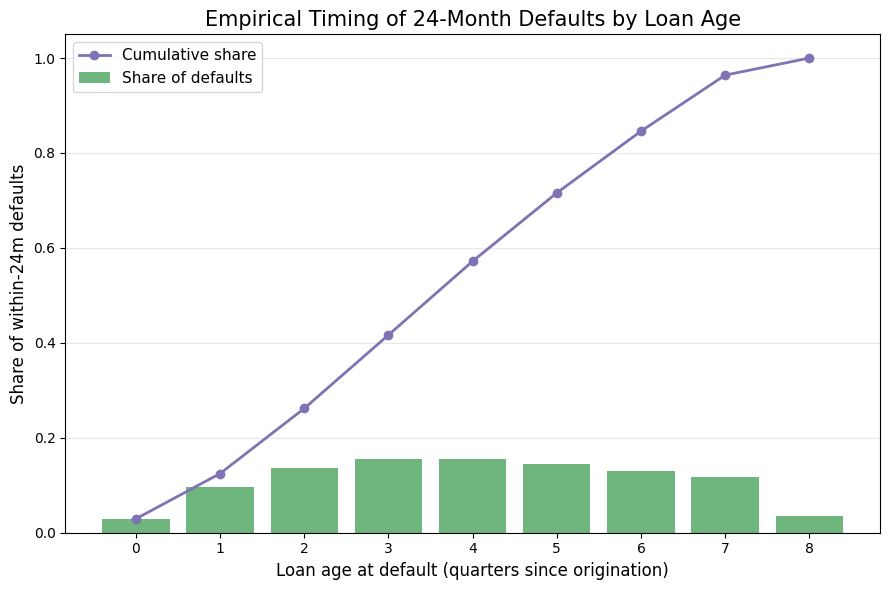

Default-timing distribution (by loan-age quarter):
 loan_age_quarter  share_of_24m_defaults  cumulative_share
                0                 0.0293            0.0293
                1                 0.0954            0.1248
                2                 0.1372            0.2620
                3                 0.1547            0.4167
                4                 0.1554            0.5720
                5                 0.1439            0.7159
                6                 0.1301            0.8460
                7                 0.1180            0.9640
                8                 0.0360            1.0000


In [132]:
# ------------------------------------------------------------
# Figure 4 — Default-timing distribution by loan age (quarters)
# ------------------------------------------------------------

# Defaulted-within-24m loans in the modeling sample, with a usable timing proxy
defaulters = df_model[
    (df_model["default_24m"] == 1) &
    (df_model["months_to_default_proxy"].notna()) &
    (df_model["months_to_default_proxy"] >= 0)
].copy()

# Age in quarters since origination, bucketed 0..8 (0-2m -> q0, ..., 24m -> q8)
age_q = (defaulters["months_to_default_proxy"] // 3).clip(lower=0, upper=8).astype(int)

timing = (
    age_q.value_counts(normalize=True)
    .reindex(range(0, 9), fill_value=0.0)
    .sort_index()
    .rename_axis("loan_age_quarter")
    .reset_index(name="share_of_24m_defaults")
)
timing["cumulative_share"] = timing["share_of_24m_defaults"].cumsum()
timing.to_csv(os.path.join(ARTIFACT_DIR, "fig1.4_default_timing_by_age.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(timing["loan_age_quarter"], timing["share_of_24m_defaults"],
       color="#55A868", alpha=0.85, label="Share of defaults")
ax.plot(timing["loan_age_quarter"], timing["cumulative_share"],
        color="#8172B3", marker="o", linewidth=2, label="Cumulative share")
ax.set_title("Empirical Timing of 24-Month Defaults by Loan Age", fontsize=15)
ax.set_xlabel("Loan age at default (quarters since origination)", fontsize=12)
ax.set_ylabel("Share of within-24m defaults", fontsize=12)
ax.set_xticks(range(0, 9))
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "fig1.4_default_timing_by_age.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Default-timing distribution (by loan-age quarter):")
print(timing.round(4).to_string(index=False))
